# Edge detection and detection of geometric primitives

**In this lecture, we will learn**
- basic of edge detection based on first and second order derivatives,
- how Canny edge detection algorithm works,
- robust line fitting using Random Sample consensus (RANSAC),
- line and circle detection using Hough transform.

**The lecture is based on**
- Chapters 5 "Edges and Contours", 10 "Fitting Straight Lines", and 12 "Detecting Geometric Primitives" of  
  [\[Burger22\] Wilhelm Burger, Mark J. Burge: *Digital Image Processing: An Algorithmic Introduction (3rd edition)*](https://imagingbook.com/books/english-edition-hardcover/)

In [1]:
from typing import Literal

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
import skimage

In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
np.set_printoptions(threshold=20, edgeitems=10, linewidth=140, precision=3, suppress=True)

In [3]:
def imshow_grid(
    nrows: int | None = None,
    ncols: int | None = None,
    figsize: tuple[float, float] | None = None,
    cmap: str | None = None,
    vmin: int | float | Literal['min'] = 'min',
    vmax: int | float | Literal['dtype', 'max'] = 'max',
    grid: bool = False,
    colorbar: bool = True,
    interpolation: Literal['nearest', 'bilinear'] = 'nearest',
    axis_off: bool = True,
    proportional: bool = False,
    symmetric_colorbar: bool = True,
    **images,
) -> tuple[plt.Figure, np.ndarray]:
    if nrows is None:
        nrows = 1
    if ncols is None:
        ncols = -int(-len(images) // nrows)  # ceil
    if figsize is None:
        fig_size_y = sum(img.shape[0] / img.shape[1] for img in images.values()) / len(images) * nrows * plt.rcParams['figure.figsize'][1]
        fig_size_x = max(1, (ncols + 1) / 2) * plt.rcParams['figure.figsize'][0]
    else:
        fig_size_x, fig_size_y = figsize
    if proportional:
        if nrows > 1:
            raise ValueError
        gridspec_kw = {'width_ratios': [img.shape[1] for img in images.values()]}
    else:
        gridspec_kw = None
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_size_x, fig_size_y), layout='constrained', gridspec_kw=gridspec_kw)
    axes = np.atleast_1d(axes)
    im = None
    rgb_only = True
    for ax, (name, img) in zip(axes.flat, images.items()):
        _vmin = vmin
        if _vmin == 'min':
            _vmin = img.min()
        _vmax = vmax
        if _vmax == 'dtype':
            _vmax = np.iinfo(img.dtype).max if np.issubdtype(img.dtype, np.integer) else 1.0
        elif _vmax == 'max':
            _vmax = img.max()
        if symmetric_colorbar and _vmin < 0:
            abs_max = max(abs(_vmin), abs(_vmax))
            _vmin = -abs_max
            _vmax = abs_max
        _cmap = cmap
        if _cmap is None:
            if (_vmin, _vmax) in ((0.0, 1.0), (0, 255)):
                _cmap = 'gray'
            elif _vmin >= 0:
                _cmap = plt.rcParams['image.cmap']
            else:
                _cmap = 'coolwarm'
        im = ax.imshow(img, cmap=_cmap, vmin=_vmin, vmax=_vmax, interpolation=interpolation)
        ax.grid(grid)
        ax.set_title(name)
        if axis_off:
            ax.axis('off')
        if img.ndim < 3 or img.shape[2] != 3:
            rgb_only = False
    if colorbar and im is not None and not rgb_only:
        if ncols > nrows:
            orientation = 'horizontal'
        elif ncols == nrows:
            orientation = 'horizontal' if im.get_size()[1] > im.get_size()[0] else 'vertical'
        else:
            orientation = 'vertical'
        if vmin == 'min' or vmax == 'max':
            for ax in axes.flat[: len(images)]:
                fig.colorbar(ax.images[0], ax=ax, orientation=orientation, aspect=30)
        else:
            fig.colorbar(im, ax=axes, orientation=orientation, aspect=50)
    return fig, axes

In [4]:
robot_rgb = skimage.io.imread('../data/robot.png')
robot_rgb = skimage.util.img_as_float(robot_rgb)
robot_rgb.shape, robot_rgb.dtype, robot_rgb.min(), robot_rgb.max()

((234, 160, 3), dtype('float64'), np.float64(0.0), np.float64(1.0))

In [5]:
robot_gray = skimage.color.rgb2gray(robot_rgb)
robot_gray.shape, robot_gray.dtype, robot_gray.min(), robot_gray.max()

((234, 160), dtype('float64'), np.float64(0.0), np.float64(1.0))

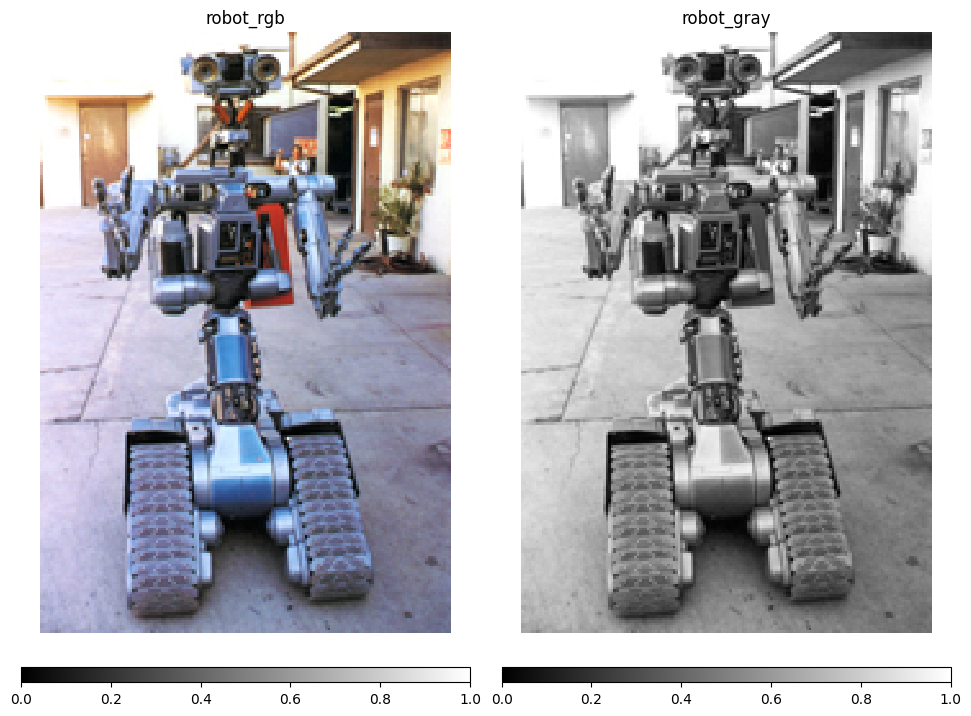

In [6]:
imshow_grid(robot_rgb=robot_rgb, robot_gray=robot_gray);

# Edge detection based on first order derivatives

## Edges as gradients

- Edges correspond to changes in brightness and can be enhanced by computing derivatives.
- See the following figure, in which
  $$
  f'(x) = \frac{\text{d}f(x)}{\text{d}x}
  $$

<figure class="image">
  <img src="../figures/edge_primitives-derivative.png" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    <br>
    Source: [Burger22], Fig. 5.2
  </figcaption>
</figure>

- Since we're dealing with discrete functions, we can only approximate derivatives using differences.
- Most commonly, central symmetric difference is used:
  $$
  \frac{\text{d}f(x)}{\text{d}x} \approx \frac{ f(x+1)-f(x-1) }{ 2 }
  $$
- In 2D, we need to compute the derivatives along all dimensions (axes) of our input, i.e. for both $x$ and $y$.
- These are called **partial derivatives** and for a 2D image $I$ we'll abbreviate them as $I_x$ and $I_y$, i.e.  
  $$
  I_x(x,y) = \frac{ \partial I(x,y) } { \partial x } \qquad \text{and} \qquad I_y(x, y) = \frac{ \partial I(x,y) } { \partial y }
  $$
- We may organize the partial derivatives into a vector called the **gradient**, which for the 2D case is  
  $$
  \nabla I(x,y) = \begin{bmatrix}
      I_x(x,y) \\
      I_y(x,y)
  \end{bmatrix}
  $$
- An $L_2$ norm of the gradient vector is called the **magnitude**, i.e.  
  $$
  \left\lVert \nabla I \right\rVert = \sqrt{I_x^2 + I_y^2}
  $$
- The magnitude is invariant to image rotations, which is useful for making edge detection robust against image transformations.
- Being a vector, the gradient also has an **orientation** angle  
  $$
  \Phi(x, y) = \arctan\left( I_x(x, y), I_y(x, y) \right)
  $$
- The gradient always points in the direction perpendicular to the edge.

<figure class="image">
  <img src="../figures/edge_primitives-edge_gradient.png" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    Edge gradient. E(u, v) denotes the gradient magnitude.
    <br>
    Source: [Burger22], Fig. 5.5
  </figcaption>
</figure>

## Gradient computation using convolution

- We may treat the gradient computation as a convolution with derivative filters.
- For $x$ and $y$ directions, respectively, the filters are
  $$
  h_x = \begin{bmatrix}
      0.5 & 0 & -0.5
  \end{bmatrix}
  \qquad
  \text{and}
  \qquad
  h_y = \begin{bmatrix}
       0.5 \\
       0 \\
      -0.5
  \end{bmatrix}
  $$
- Notice the reverse signs - this is because before convolution means correlating with horizontally and vertically flipped filters.

In [7]:
# Generate super-gaussian function
targets, data = np.mgrid[-3:3.1:0.1,-3:3.1:0.1]
s, p = 2, 1
f = np.exp(-0.5 * ((data**2 + targets**2) / s) ** (2*p))
f.shape, f.dtype, f.min(), f.max()

((61, 61),
 dtype('float64'),
 np.float64(2.576757109154981e-18),
 np.float64(1.0))

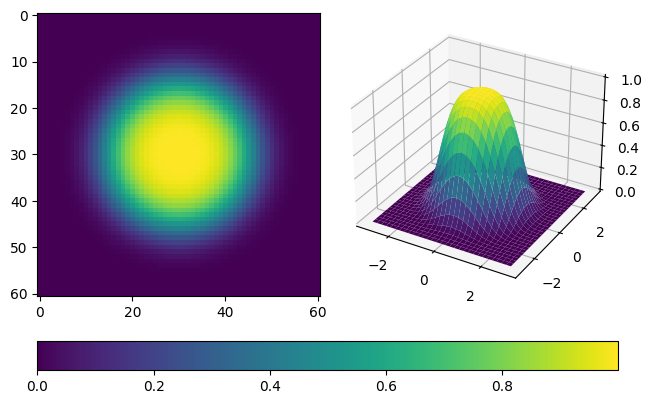

In [8]:
fig = plt.figure()
ax0 = fig.add_subplot(1, 2, 1)
im = ax0.imshow(f)
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
sf = ax1.plot_surface(data, targets, f, cmap=im.cmap, linewidth=0);
fig.colorbar(sf, ax=[ax0, ax1], location='bottom');

In [9]:
# Create simple finite difference kernels
h_dx = 0.5 * np.array([[1, 0, -1]])
h_dy = h_dx.T

# Compute the gradient by convolution with finite difference kernels
f_dx = scipy.ndimage.convolve(f, h_dx)
f_dy = scipy.ndimage.convolve(f, h_dy)
f_mag = np.sqrt(f_dx ** 2 + f_dy ** 2)

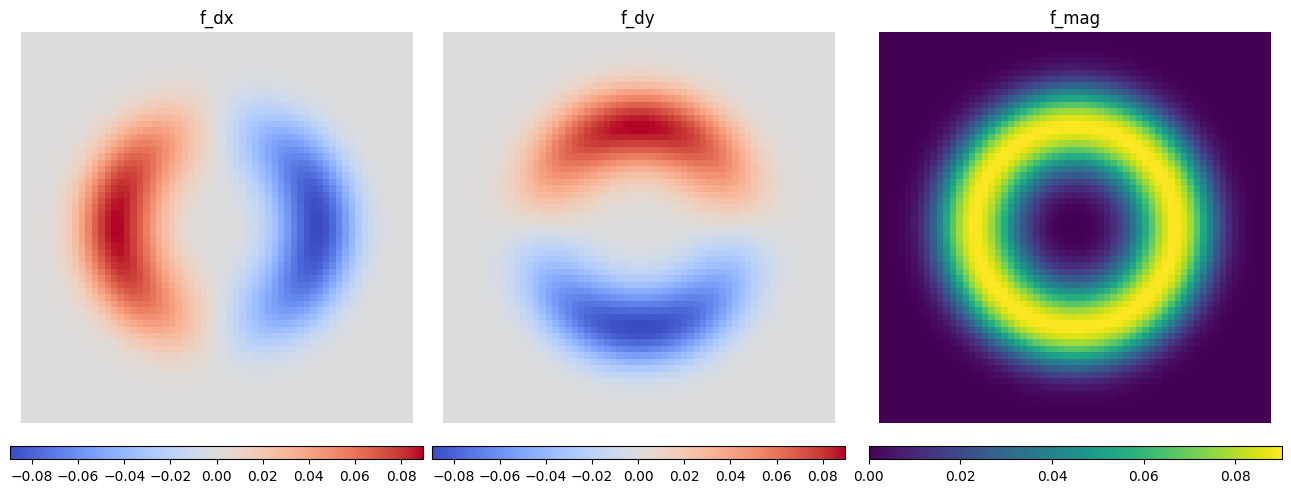

In [10]:
imshow_grid(f_dx=f_dx, f_dy=f_dy, f_mag=f_mag);

## Common edge detection kernels

- Usually, edge detection kernels operate over a small neighborhood around each pixel in order to increase robustness against noise.
- Some examples are
  - Roberts
  - Prewitt
  - Sobel
  - Improved Sobel

In [11]:
edge_kernels = {
    'roberts': np.array([
        [0., 1.],
        [-1., 0.],
    ]),
    'prewitt': np.array([
        [-1., 0., 1.],
        [-1., 0., 1.],
        [-1., 0., 1.],
    ]),
    'sobel': np.array([
        [-1., 0., 1.],
        [-2., 0., 2.],
        [-1., 0., 1.],
    ]),
    'improved_sobel': np.array([
        [-3., 0., 3.],
        [-10., 0., 10.],
        [-3., 0., 3.],
    ]),
}

In [12]:
# Kernel-based derivatives in x and y directions
robot_dxys = {
    f'{name}_{d}': 2 / np.abs(kernel).sum() * scipy.ndimage.convolve(robot_gray, kernel if d == 'x' else kernel.T)
    for name, kernel in edge_kernels.items()
    for d in ('x', 'y')
}

In [13]:
# Gradient magnitudes
robot_dmags = {
    name: (robot_dxys[f"{name}_x"] ** 2 + robot_dxys[f"{name}_y"] ** 2) ** 0.5
    for name in edge_kernels
}

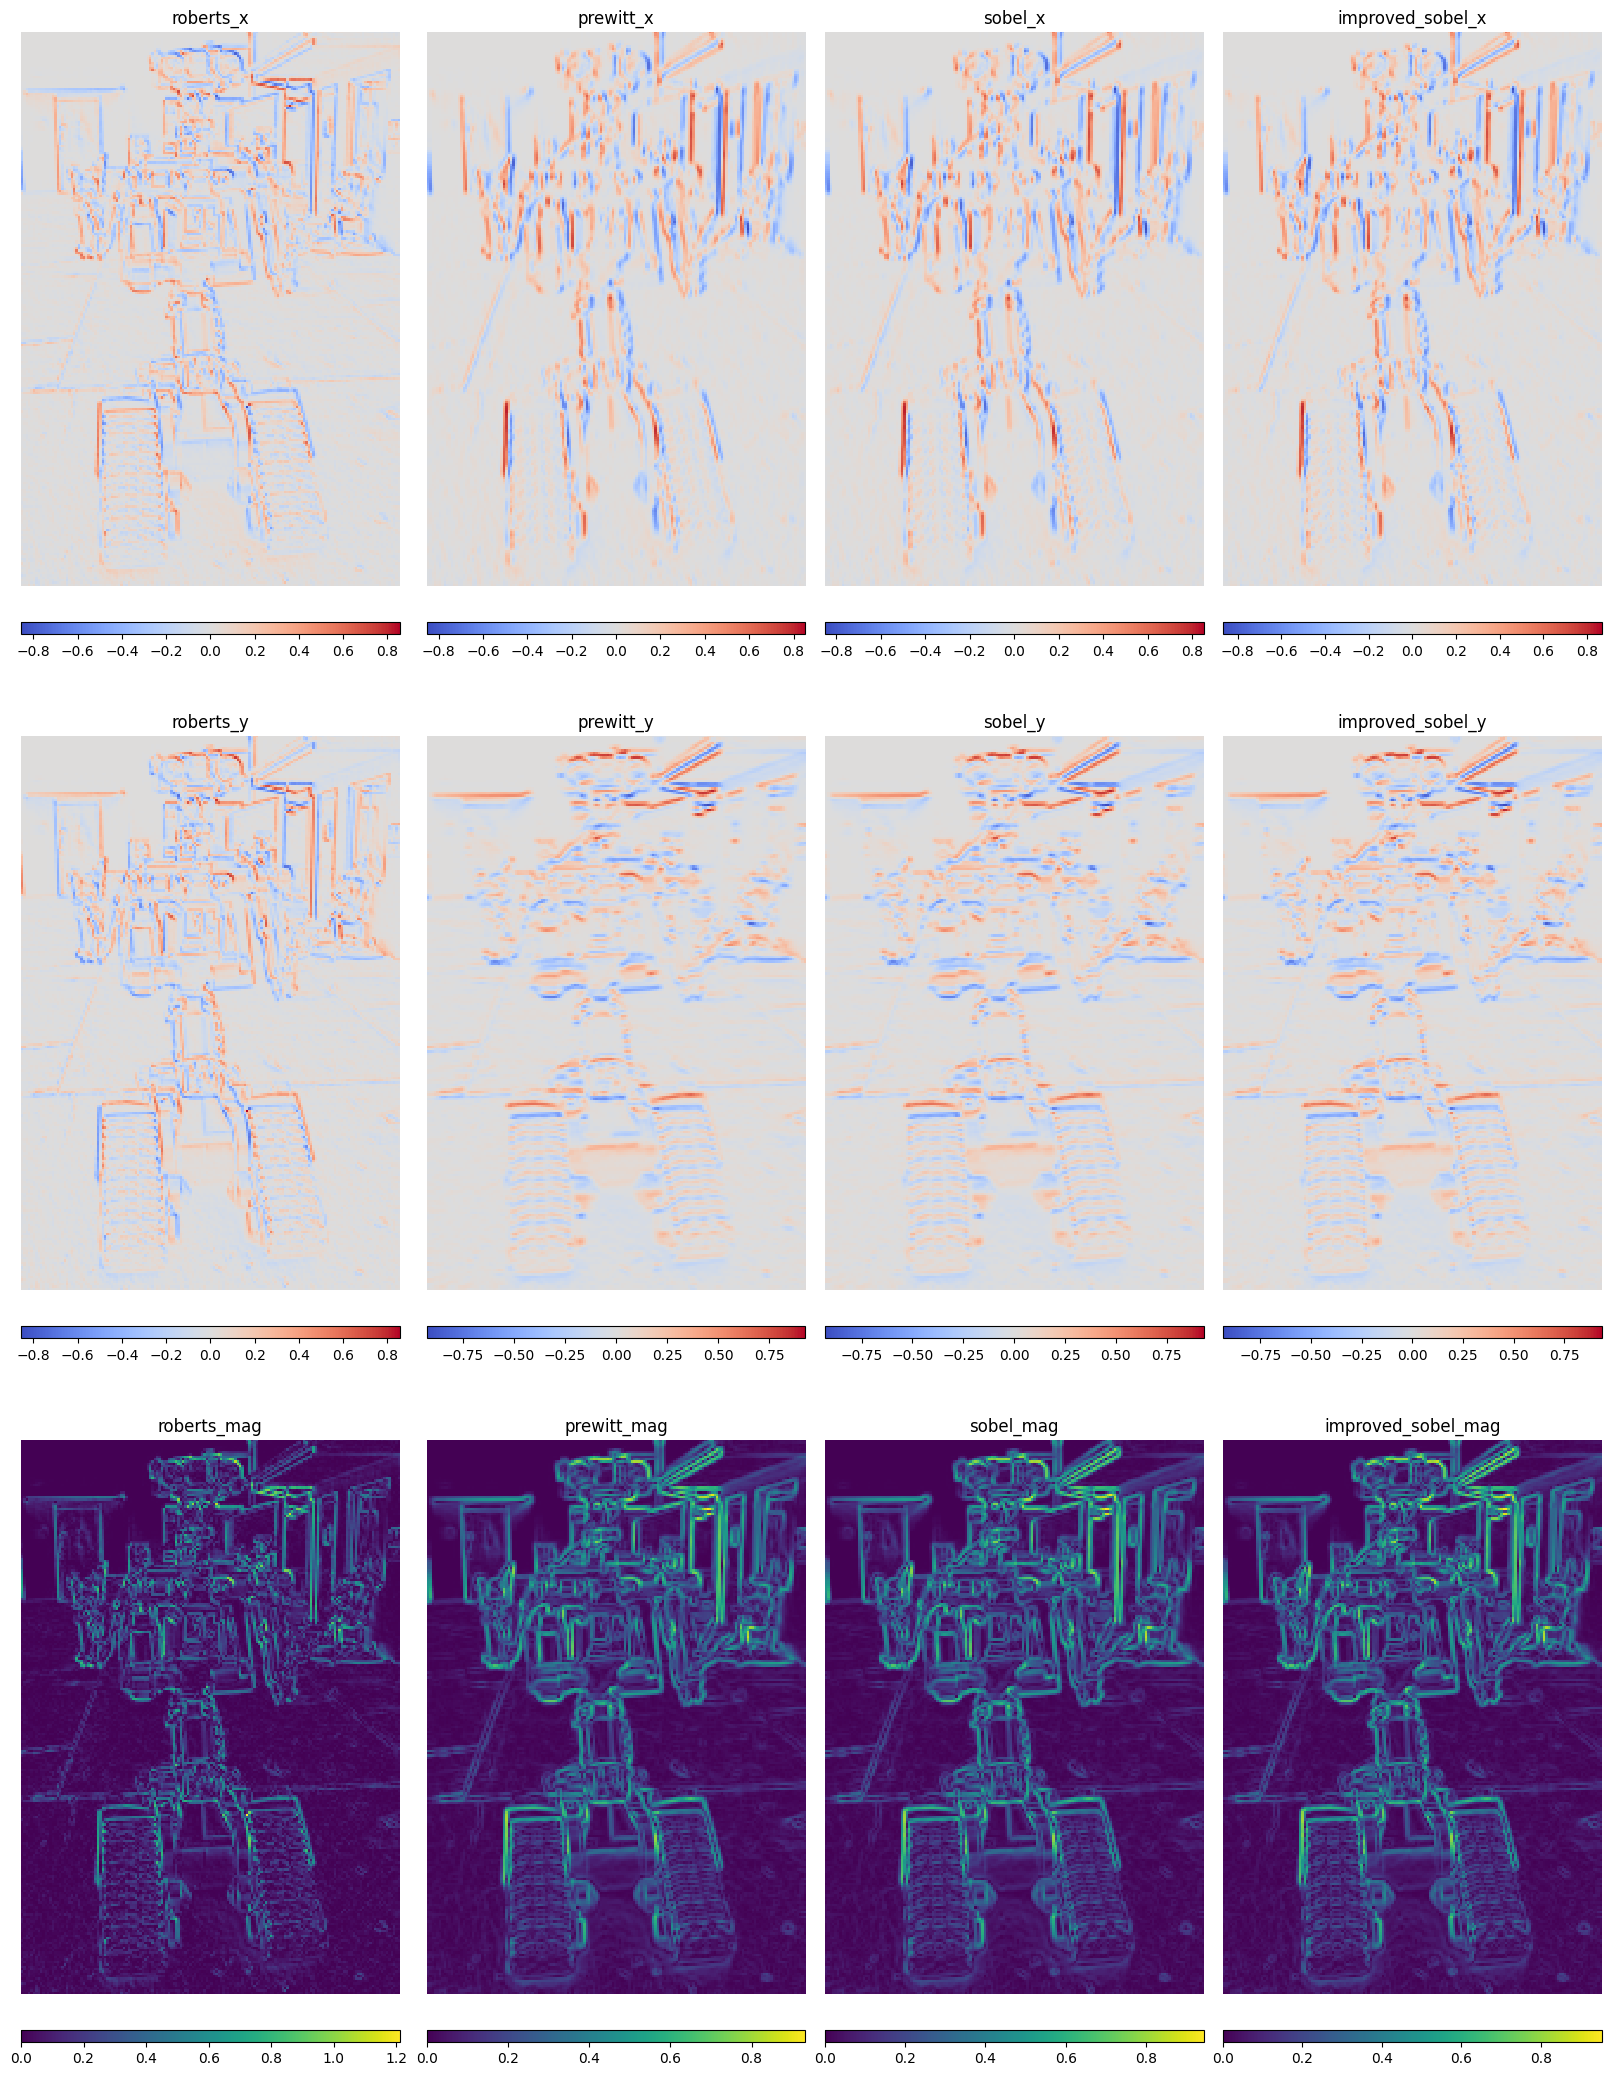

In [14]:
imshow_grid(
    3,
    **{n: d for n, d in robot_dxys.items() if n.endswith('_x')},
    **{n: d for n, d in robot_dxys.items() if n.endswith('_y')},
    **{f'{n}_mag': mag for n, mag in robot_dmags.items()},
);

## Compass operators

- Compass operators detect edges in several directions and then define the response for each point as the *maximum over all directions*.

In [15]:
def create_kernel(h: np.ndarray) -> np.ndarray:
    return np.array([
        [h[0], h[1], h[2]],
        [h[7],    0, h[3]],
        [h[6], h[5], h[4]],
    ])

compass_kernels = {
    'compass_sobel': np.array([1, 2, 1, 0, -1, -2, -1, 0], dtype=float),
    'compass_kirsch': np.array([-5, -5, 3, 3, 3, 3, 3, -5], dtype=float)
}
compass_kernels = {
    name: np.array([create_kernel(np.roll(vals, r)) for r in range(8)])
    for name, vals in compass_kernels.items()
}
compass_kernels

{'compass_sobel': array([[[ 1.,  2.,  1.],
         [ 0.,  0.,  0.],
         [-1., -2., -1.]],
 
        [[ 0.,  1.,  2.],
         [-1.,  0.,  1.],
         [-2., -1.,  0.]],
 
        [[-1.,  0.,  1.],
         [-2.,  0.,  2.],
         [-1.,  0.,  1.]],
 
        [[-2., -1.,  0.],
         [-1.,  0.,  1.],
         [ 0.,  1.,  2.]],
 
        [[-1., -2., -1.],
         [ 0.,  0.,  0.],
         [ 1.,  2.,  1.]],
 
        [[ 0., -1., -2.],
         [ 1.,  0., -1.],
         [ 2.,  1.,  0.]],
 
        [[ 1.,  0., -1.],
         [ 2.,  0., -2.],
         [ 1.,  0., -1.]],
 
        [[ 2.,  1.,  0.],
         [ 1.,  0., -1.],
         [ 0., -1., -2.]]], shape=(8, 3, 3)),
 'compass_kirsch': array([[[-5., -5.,  3.],
         [-5.,  0.,  3.],
         [ 3.,  3.,  3.]],
 
        [[-5., -5., -5.],
         [ 3.,  0.,  3.],
         [ 3.,  3.,  3.]],
 
        [[ 3., -5., -5.],
         [ 3.,  0., -5.],
         [ 3.,  3.,  3.]],
 
        [[ 3.,  3., -5.],
         [ 3.,  0., -5.],
     

In [16]:
# Convolve with all directional (compass) filters
robot_comps = {
    name: np.array([
        2 / np.abs(kernel).sum() * scipy.ndimage.convolve(robot_gray, kernel)
        for kernel in kernels
    ])
    for name, kernels in compass_kernels.items()
}

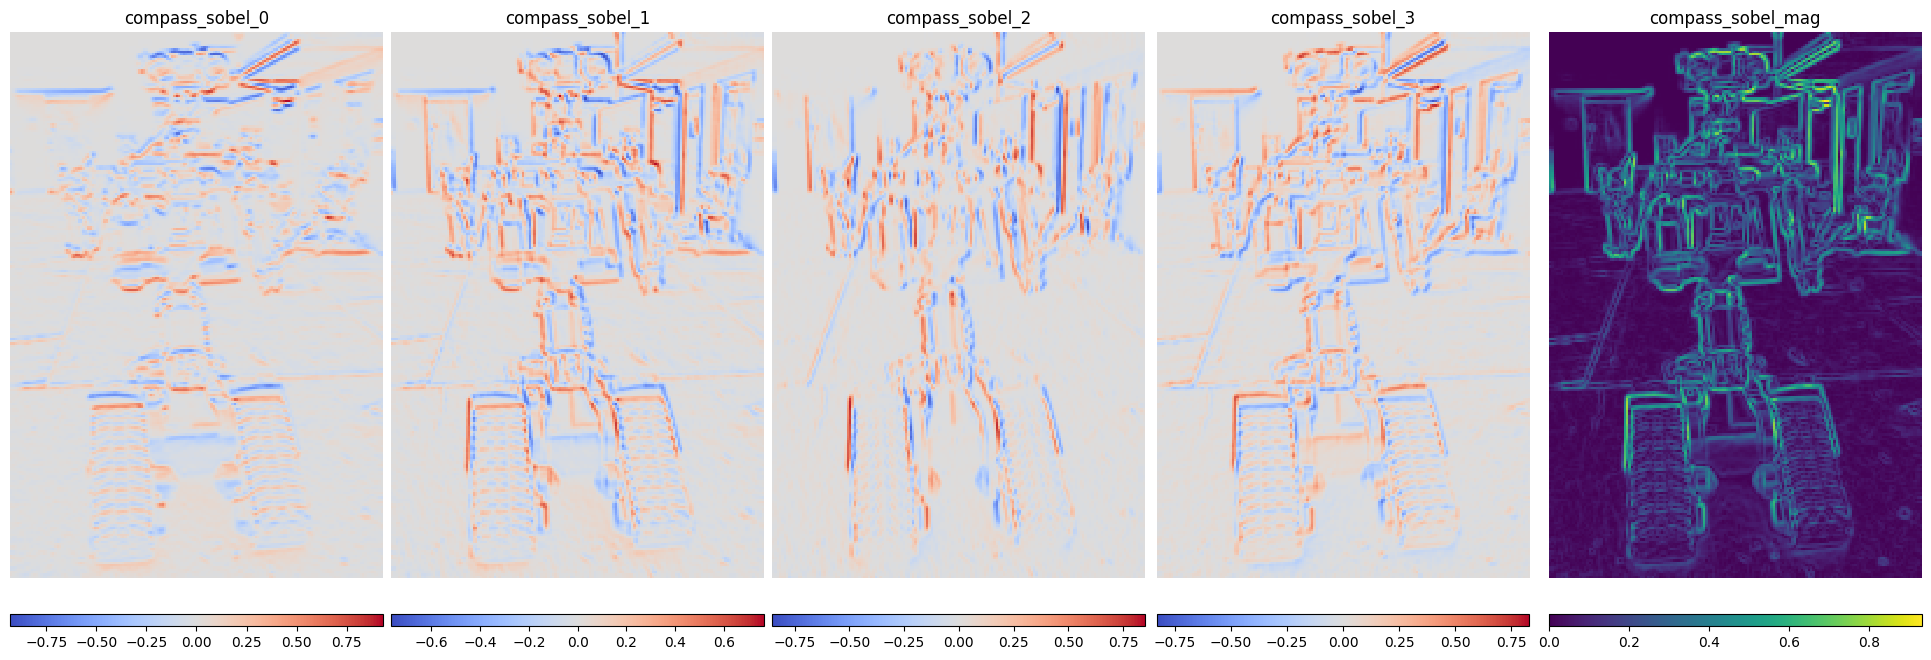

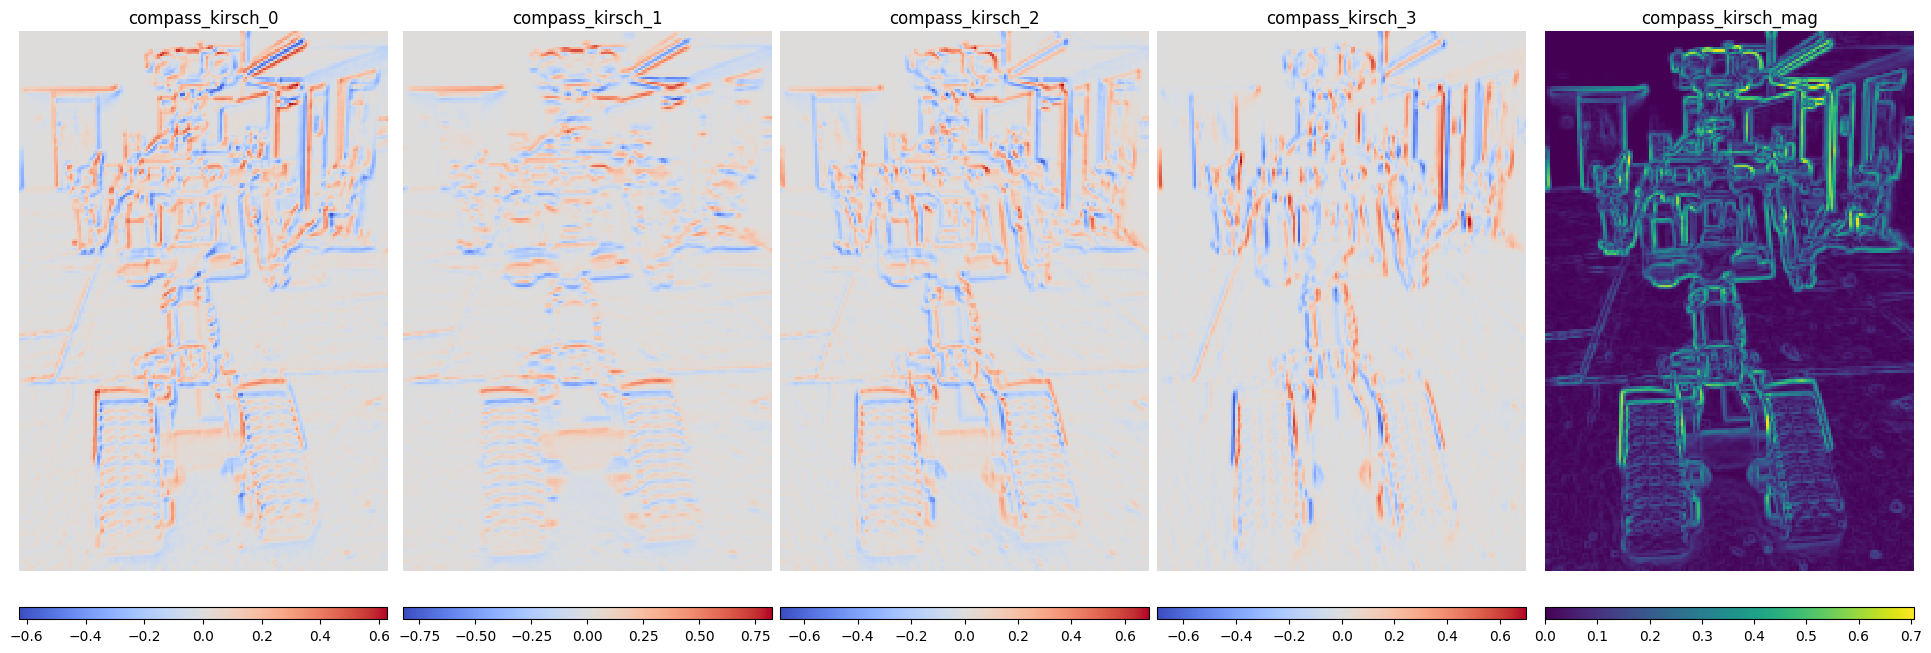

In [17]:
for n in robot_comps:
    mag = robot_comps[n].max(axis=0)  # magnitude is the maximum response over all directions
    imshow_grid(**{f'{n}_{i}': robot_comps[n][i] for i in range(4)}, **{f'{n}_mag': mag});

## Locating edges by thresholding magnitude of the first derivative

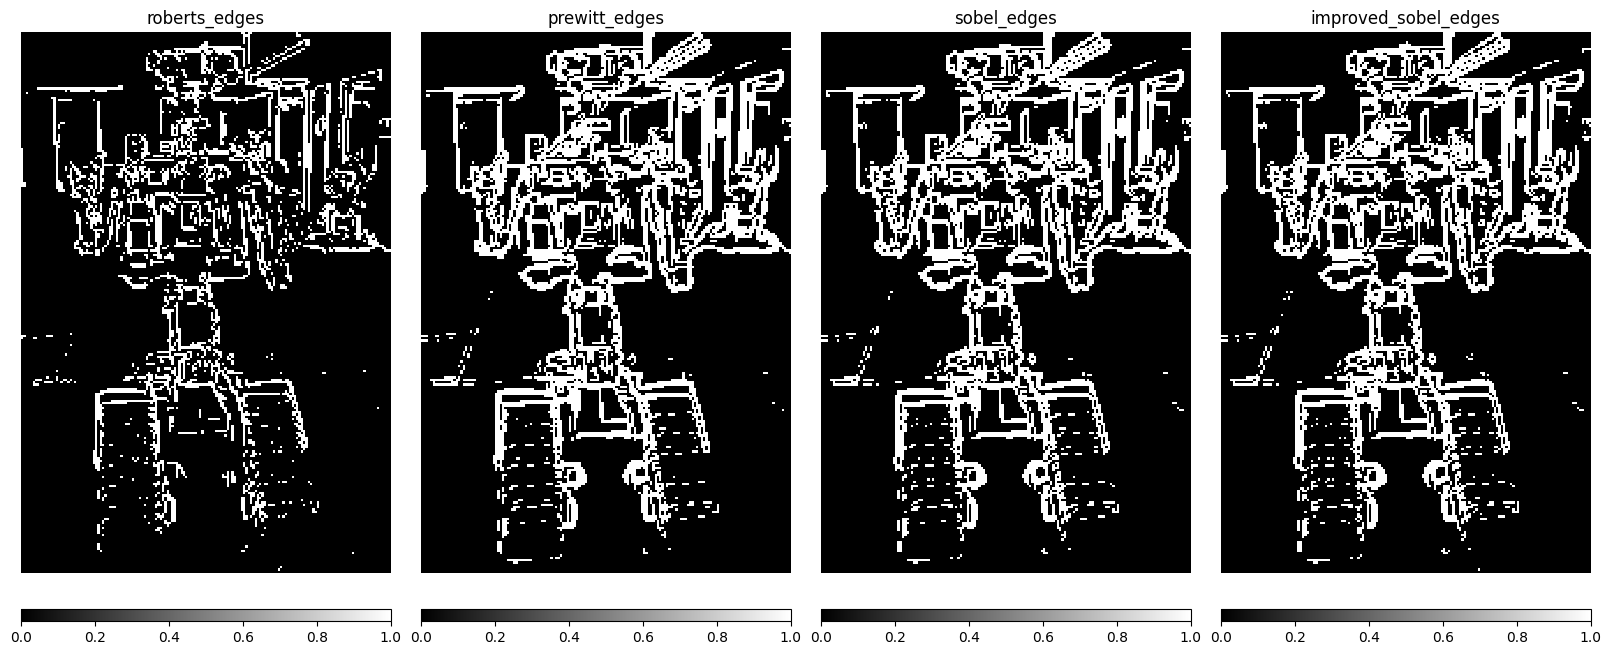

In [18]:
imshow_grid(**{f'{n}_edges': mag > 0.2 * mag.max() for n, mag in robot_dmags.items()});

## Locating edges as local maxima

In [19]:
def non_max_suppression(img: np.ndarray) -> np.ndarray:
    height, width = img.shape
    nms = np.pad(img, pad_width=1, mode='constant', constant_values=0)
    for i in range(1, height + 1):
        for j in range(1, width + 1):
            local_patch = nms[i-1:i+2, j-1:j+2]
            if nms[i,j] < local_patch.max():
                nms[i,j] = 0
    return nms[1:-1, 1:-1]

In [20]:
# Apply non-oriented non-maximum suppresion
robot_dmag_nmss = {
    name: non_max_suppression(robot_dmags[name])
    for name in robot_dmags
}

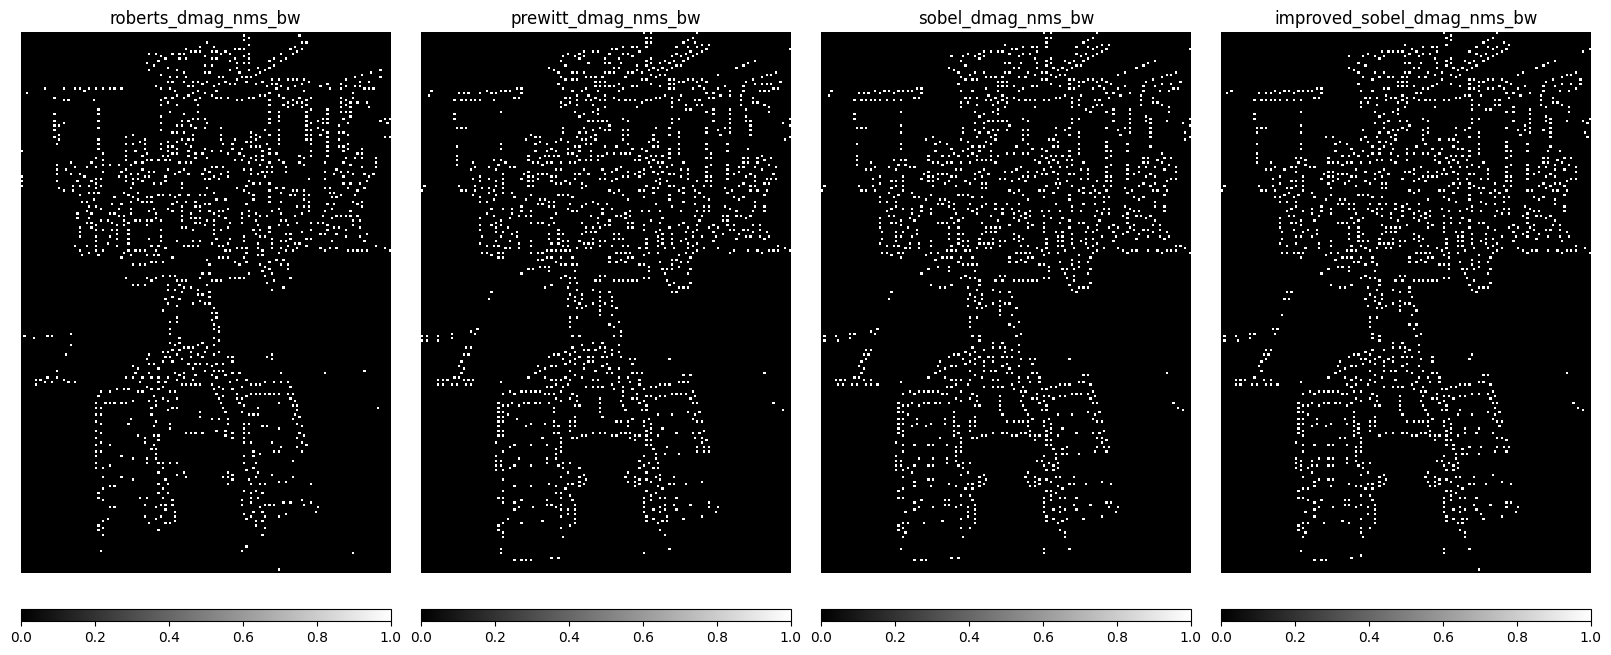

In [21]:
imshow_grid(**{f'{n}_dmag_nms_bw': nms > 0.2 * nms.max() for n, nms in robot_dmag_nmss.items()});

## Locating edges as *directional* local maxima

- Only those pixels whose gradient have the highest magnitude than their two immediate neighbors are kept as potential edges.
- Each pixel is compared to the neighbors lying *in the direction of the gradient*, i.e. perpendicular to the edge, see the following ilustration.
- In practice, gradient orientations are quantized into 4 bins, i.e. only 4 possible gradient directions are considered.

<figure class="image">
  <img src="../figures/edge_primitives-canny_nms.png" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    <br>
    Source: [Burger22], Fig. 5.12
  </figcaption>
</figure>

In [22]:
def oriented_non_max_suppresion(mag: np.ndarray, angle: np.ndarray) -> np.ndarray:
    ori_bin = ((angle + np.pi / 8) // (np.pi / 4) % 4).astype(int)
    height, width = mag.shape

    nms = mag.copy()
    mag = np.pad(mag, pad_width=1, mode='constant', constant_values=0)
    for i in range(1, 1 + height):
        for j in range(1, 1 + width):
            bin = ori_bin[i - 1, j - 1]
            val = mag[i, j]
            if bin == 0:  # right
                neighbors = [mag[i, j - 1], mag[i, j + 1]]
            elif bin == 1:  # down-right (because y axis is downwards)
                neighbors = [mag[i - 1, j - 1], mag[i + 1, j + 1]]
            elif bin == 2:  # down
                neighbors = [mag[i - 1, j], mag[i + 1, j]]
            else:  # bin == 3: down-left
                neighbors = [mag[i - 1, j + 1], mag[i + 1, j - 1]]
            if val < max(neighbors):
                nms[i - 1, j - 1] = 0
    return nms

In [23]:
# Compute gradient angles
robot_dangs = {
    name: np.arctan2(robot_dxys[f"{name}_y"], robot_dxys[f"{name}_x"])
    for name in ('roberts', 'prewitt', 'sobel', 'improved_sobel')
}

# Apply oriented non-maximum suppresion
robot_grad_nmss = {
    name: oriented_non_max_suppresion(robot_dmags[name], robot_dangs[name])
    for name in robot_dmags
}

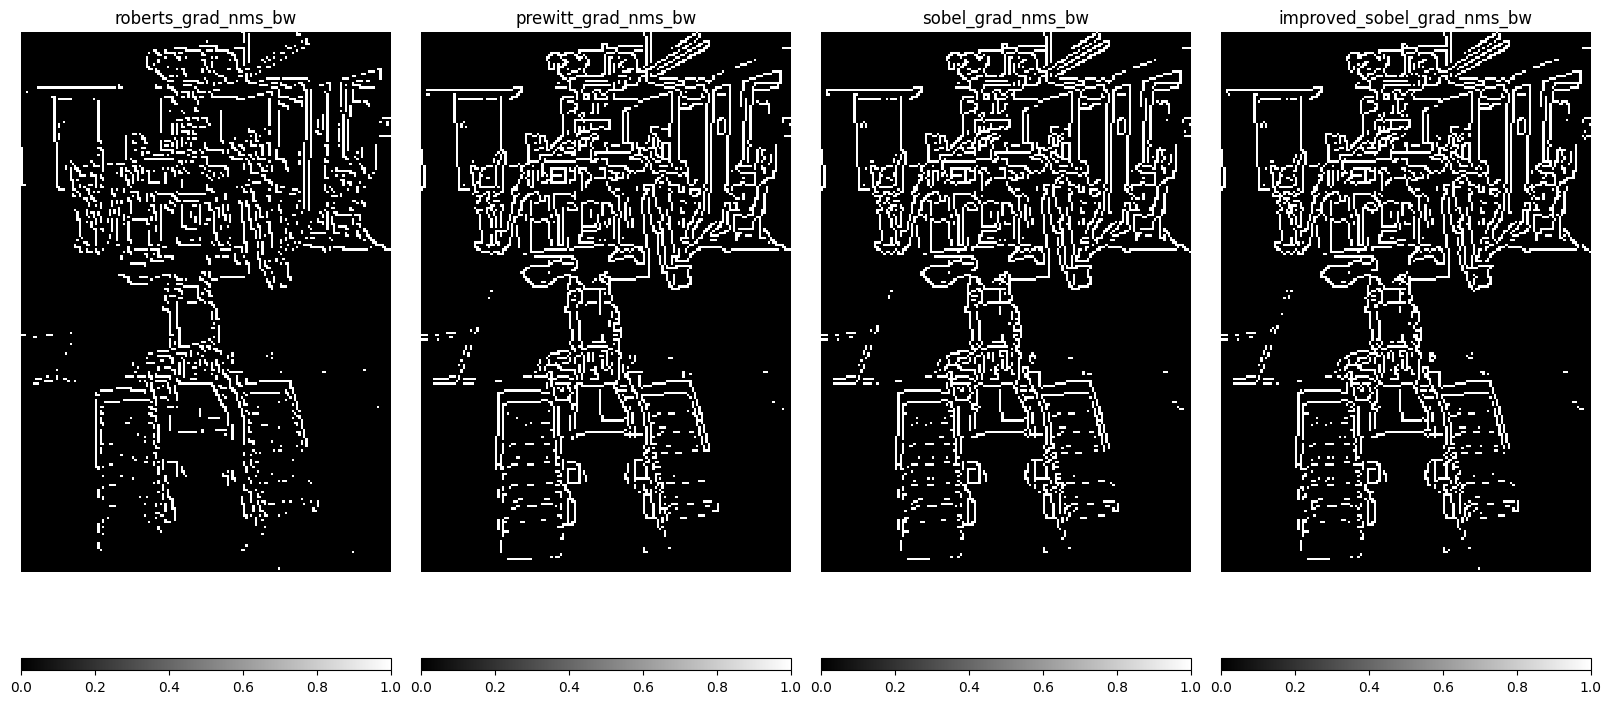

In [24]:
imshow_grid(**{f'{n}_grad_nms_bw': nms > 0.2 * nms.max() for n, nms in robot_grad_nmss.items()}, figsize=(16, 16));

# Edge dection based on second derivatives

- One problem with gradient-based edge operators based on first derivatives is that each resulting edge is as wide as the underlying intensity transition and thus edges might may be poorly localized.
- Alternative methods that localize edges as zero-crossings of the second derivative try to improve this.

<figure class="image">
  <img src="../figures/edge_primitives-second_derivative.png" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    <br>
    Source: [Burger22], Fig. 5.10
  </figcaption>
</figure>

## Laplacian filter

- Laplace operator is defined as a summation of the second derivatives.
- In 2D, that is
  $$
  \nabla^2I(x,y) = I_{xx}(x,y) + I_{yy}(x,y)
  $$
  where
  $$
  I_{xx} = \frac{\partial^2I}{\partial x^2}, \qquad I_{yy} = \frac{\partial^2I}{\partial y^2}
  $$
- Again, since we have discrete images, we'll aproximate the 2nd order derivatives using differences.

In [25]:
h_d = np.array([[1, -1]])
h_dd = scipy.signal.convolve2d(h_d, h_d)  # 2nd derivative filter
h_dd

array([[ 1, -2,  1]])

In [26]:
# 2nd derivative in x direction
h_ddx = np.pad(h_dd, ((1, 1), (0, 0)))
h_ddx

array([[ 0,  0,  0],
       [ 1, -2,  1],
       [ 0,  0,  0]])

In [27]:
# 2nd derivative in y direction
h_ddy = h_ddx.T
h_ddy

array([[ 0,  1,  0],
       [ 0, -2,  0],
       [ 0,  1,  0]])

In [28]:
# Laplacian filter
h_lap = h_ddx + h_ddy
h_lap

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

- There are actually at least four filter versions approximating the Laplacian operator, which depend on how we define image connectivity.

In [29]:
laplace_kernels = {
    'laplace_conn_4': np.array([
        [ 0,  1,  0 ],
        [ 1, -4,  1 ],
        [ 0,  1,  0],
    ]),
    'laplace_conn_8': np.array([
        [ 1,  1,  1 ],
        [ 1, -8,  1 ],
        [ 1,  1,  1],
    ]),
    'laplace_conn_8_alt1': np.array([
        [ 2, -1,  2 ],
        [-1, -4, -1 ],
        [ 2, -1,  2],
    ]),
    'laplace_conn_8_alt2': np.array([
        [-1,  2, -1],
        [ 2, -4,  2],
        [-1,  2, -1],
    ]),
}

In [30]:
# Laplacian kernel responses
robot_laps = {
    name: scipy.ndimage.convolve(robot_gray, kernel)
    for name, kernel in laplace_kernels.items()
}

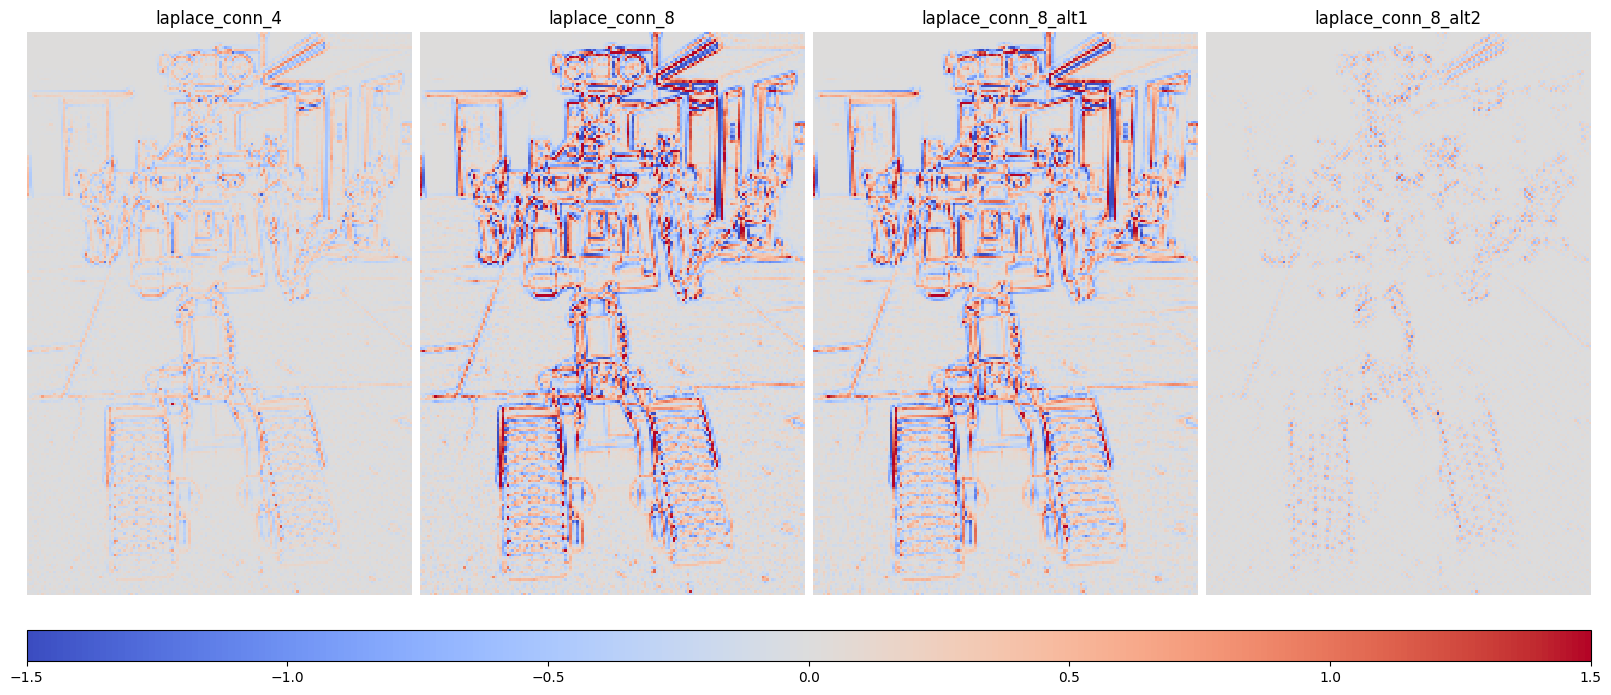

In [31]:
imshow_grid(**robot_laps, vmin=-1.5, vmax=1.5);

## Locating edges as zero-crossings of the second derivative

- Location of edges might be detected as zero crossings of the Laplacian responses.
- However, due to very large number of such crossings, we'll also need to further filter them out by looking at the gradient magnitude at corresponding positions.

In [32]:
def zero_cross_2d(mat: np.ndarray):
    dil = skimage.morphology.binary_dilation(mat > 0)
    return np.logical_and(dil, mat < 0)

In [33]:
robot_lap_zc_bws = {name: np.zeros(dlks.shape, dtype=bool) for name, dlks in robot_laps.items()}
for name in robot_laps:
    robot_lap_zc_bws[name] = zero_cross_2d(robot_laps[name])
    robot_lap_zc_bws[name][robot_dmags['improved_sobel'] < 0.1] = False  # filter out weak edges

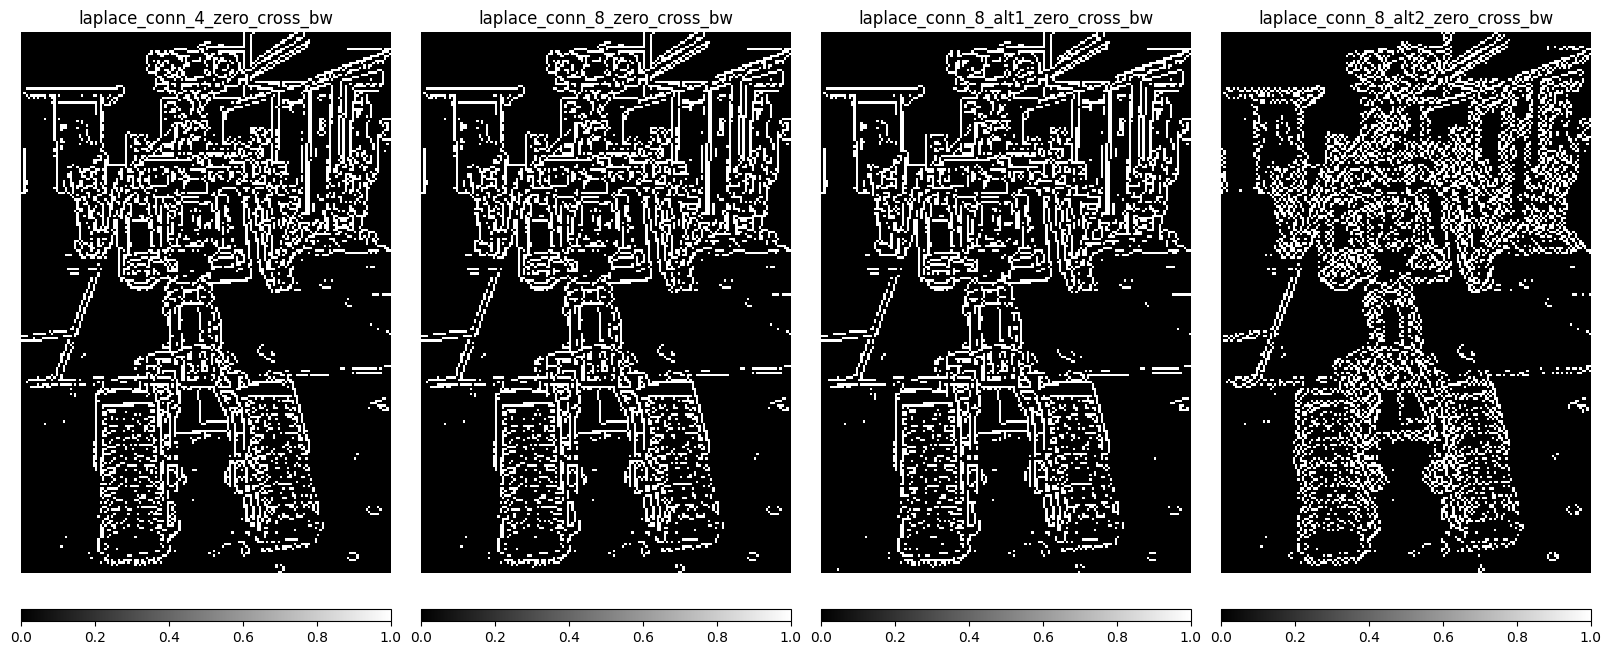

In [34]:
imshow_grid(**{f'{n}_zero_cross_bw': bw for n, bw in robot_lap_zc_bws.items()});

## Laplacian edge sharpening

- Laplacian operator $\nabla^2$ is useful for image sharpening.
- Image can be sharpened as
  $$
  I' = I - \alpha \cdot \nabla^2I(x,y)
  $$
  where
  -  $0 \lt \alpha \lt 1$ is a hyper-parameter controlling the amount of sharpening,
  -  $*$ denotes convolution.
- The following image illustrates the idea of subtracting the 2nd serivative from the original.

<figure class="image">
  <img src="../figures/edge_primitives-sharpening.png" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    <br>
    Source: [Burger22], Fig. 5.16
  </figcaption>
</figure>

In [35]:
robot_sharps = {
    name: np.clip(robot_gray - 0.3 * scipy.ndimage.convolve(robot_gray, kernel), 0., 1.)
    for name, kernel in laplace_kernels.items()
}

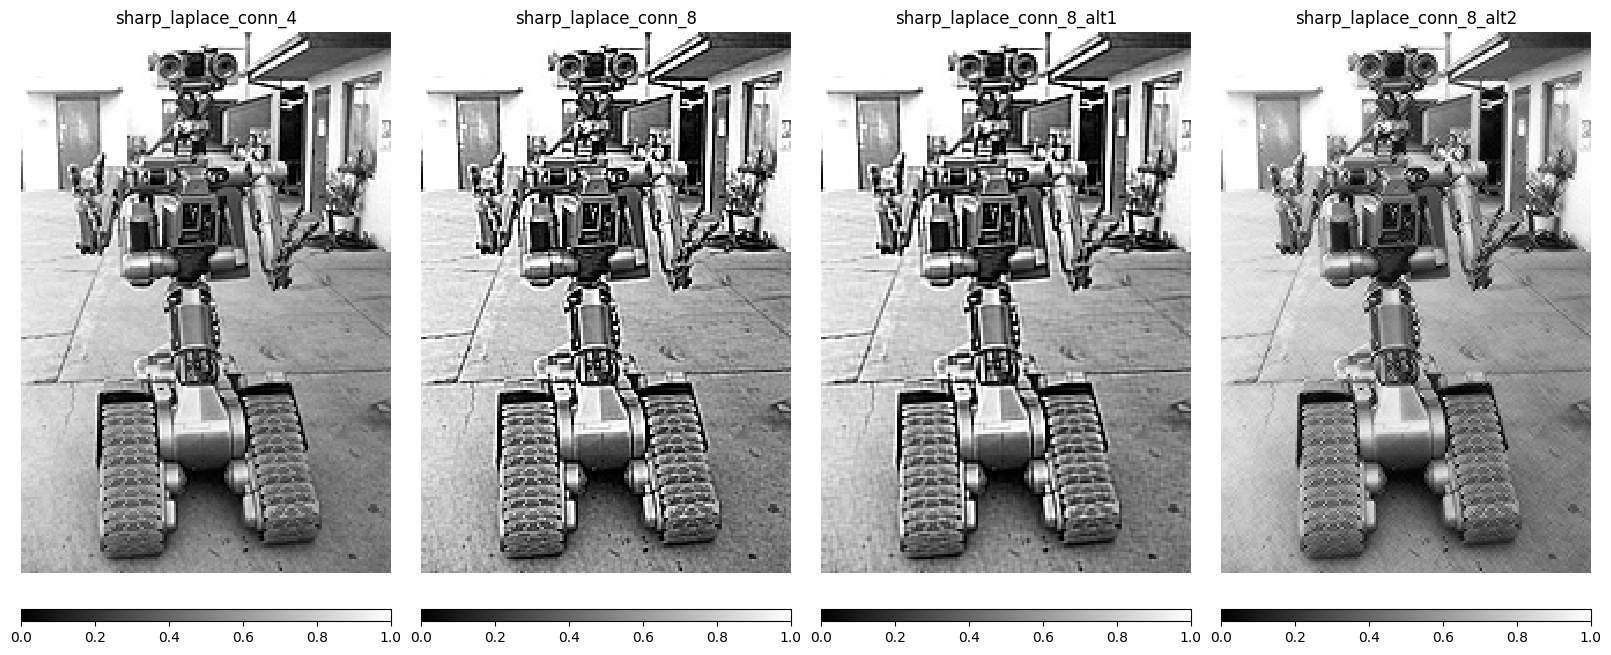

In [36]:
imshow_grid(**{f'sharp_{n}': sharp for n, sharp in robot_sharps.items()});

# Canny edge detection

- Widely used and still considered state of the art method of edge detection.
- It has several principal stages:
  1. Preprocessing.
     - Reduce noise by blurring the input image using a Gaussian filter with some $\sigma$.
  2. Gradient computation.
     - Compute partial derivatives $I_x$ and $I_y$.
     - Typically, the Sobel filter is used.
  3. Localize edges using directional non-maximum suppression.
  4. Hysteresis thresholding.
     - Local gradient magnitude maximums that survived the preceeding step are marked as a *"strong" edge*, if their value is higher than some threshold $t_{\text{hi}}$.
     - There is, however, a second smaller threshold $t_{\text{lo}}$.
     - If a gradient magnitude falls between these two thresholds, i.e. $t_{\text{lo}} \le |\nabla I| \le t_{\text{hi}}$, it is marked as a *"weak" edge*. "Weak" edge pixels are classified as edges only if they are connected to some "sure" edge pixel.
  5. The whole procedure may be repeated for different preprocessing $\sigma$ (scales). The scale-specific results are then merged into a single binary edge image.

In [37]:
def hysteresis_thresholding(img: np.ndarray, t_lo: float = 0.2, t_hi: float = 0.5) -> np.ndarray:
    """
    Hysteresis thresholding using morphological dilation by reconstruction
    """
    strong_edges = img > t_hi  # starting markers
    weak_edges = img >= t_lo  # mask

    prev_sum = -1
    while prev_sum != strong_edges.sum():
        prev_sum = strong_edges.sum()
        strong_edges = skimage.morphology.binary_dilation(strong_edges)
        strong_edges = np.logical_and(strong_edges, weak_edges)

    return strong_edges

In [38]:
robot_grad_hthrs = {
    name: hysteresis_thresholding(robot_grad_nmss[name], 0.1, 0.3)
    for name in robot_grad_nmss
}

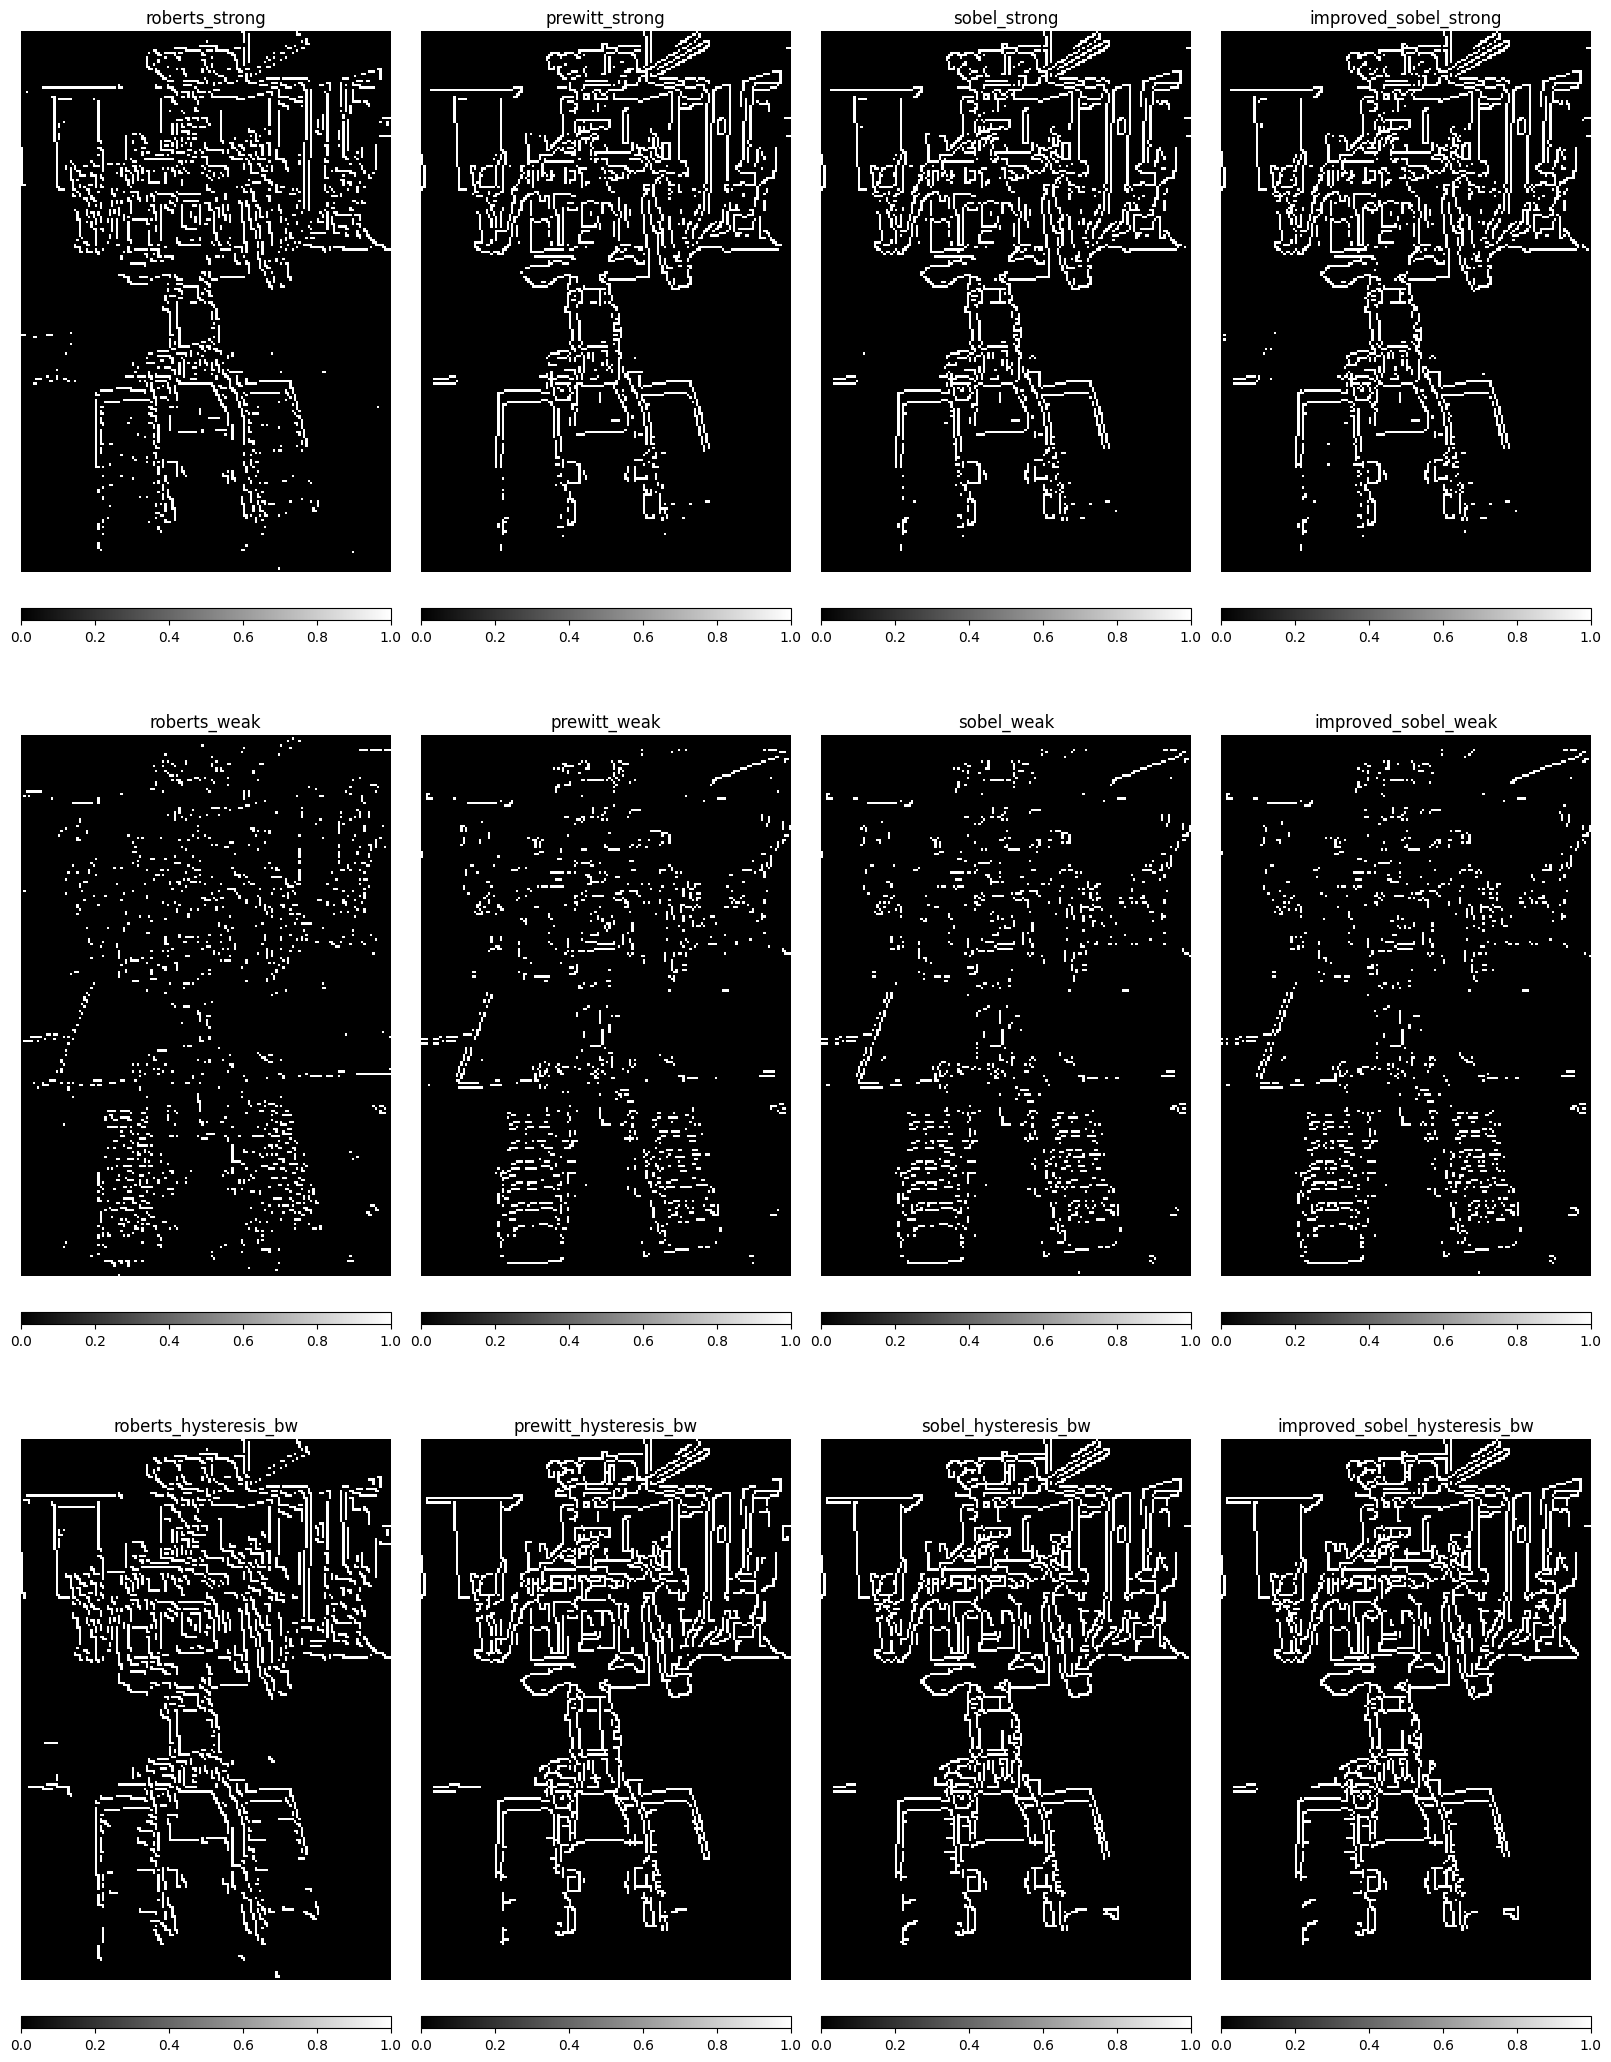

In [39]:
imshow_grid(
    3,
    **{f'{n}_strong': robot_grad_nmss[n] > 0.25 for n in robot_grad_nmss},
    **{f'{n}_weak': (robot_grad_nmss[n] >= 0.15) & (robot_grad_nmss[n] <= 0.25) for n in robot_grad_nmss},
    **{f'{n}_hysteresis_bw': robot_grad_hthrs[n] for n in robot_grad_hthrs}
);

In [40]:
def canny(
    img: np.ndarray,
    t_lo: float = 0.1,
    t_hi: float = 0.3,
    sigma: float = 1.0,
) -> np.ndarray:
    """Canny edge detector implementation"""
    # Step 1: Gaussian smoothing
    img = scipy.ndimage.gaussian_filter(img, sigma=sigma)

    # Step 2: Compute gradient using improved Sobel operator
    dx = scipy.ndimage.convolve(img, edge_kernels['sobel'])
    dy = scipy.ndimage.convolve(img, edge_kernels['sobel'].T)
    mag = np.sqrt(dx ** 2 + dy ** 2)
    angle = np.arctan2(dy, dx)

    # Step 3: Oriented non-maximum suppression
    nms = oriented_non_max_suppresion(mag, angle)

    # Step 4: Hysteresis thresholding
    edges_bw = hysteresis_thresholding(nms, t_lo, t_hi)

    return edges_bw

In [41]:
robot_canny_bws = {
    f't_lo={t_lo:.2f}, t_hi={t_hi:.2f}, sigma={sigma:.2f}': canny(robot_gray, t_lo=t_lo, t_hi=t_hi, sigma=sigma)
    for t_lo, t_hi, sigma in [
        (0.2, 0.4, 1.0),
        (0.3, 0.5, 1.0),
        (0.3, 0.5, 1.5),
        (0.4, 0.6, 1.5),
    ]
}

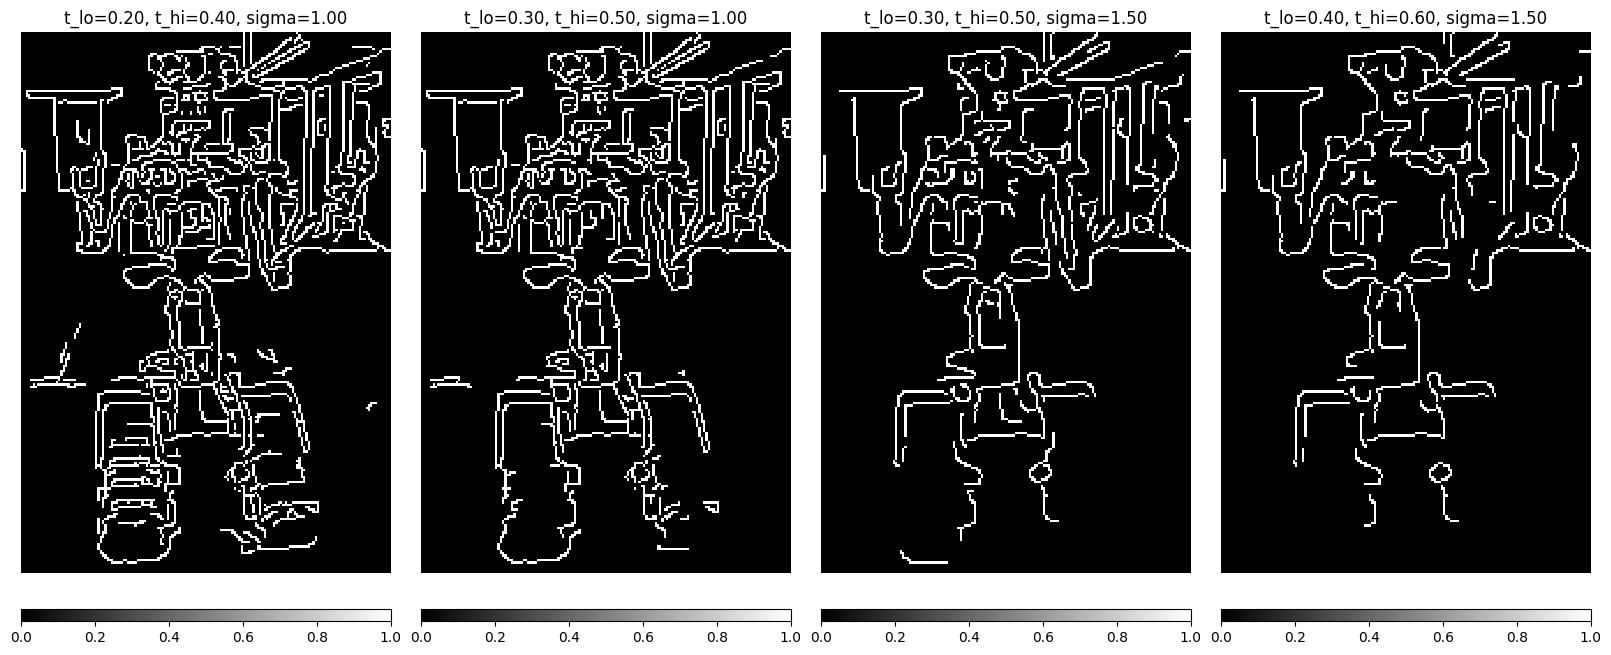

In [42]:
imshow_grid(**robot_canny_bws);

# Line fitting

- The most familiar way of representing a line in 2D is the **slope-intercept form**  
  $$
  y = k \cdot x + q
  $$
  where
  - $k$ is the slope; the larger the $k$ is, the more steeply the line is increasing in the direction of positive $x$,
  - $q$ is the intercept, i.e. where the line crosses the $y$ axis.

<figure class="image">
  <img src="../figures/edge_primitives-line_slope_intercept.svg" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    <br>
    Source: <a>https://en.wikipedia.org/wiki/Linear_equation</a>
  </figcaption>
</figure>

## Linear regression

<figure class="image">
  <img src="../figures/edge_primitives-linear_regression.png" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    <br>
    Source: [Burger22], Fig. 10.3
  </figcaption>
</figure>

- Imagine we have set of $N$ 2D points $\mathcal{X} = \{(x_n, y_n)\}_{n=1}^{N}$ and we want to find the line $y = k^* \cdot x + q^*$ that passes through the points as closely as possible.
- Formally, this can be formulated as a minimization of the sum of residuals  
  $$
  k^*, q^* = \argmin_{k,q}{ L(k, q) }
  $$
  where  
  $$
  L(k, q) = \sum_{n=1}^{N}{ \left(y_n - k \cdot x_n + q\right)^2 }
  $$
- The solution can be found by setting the partial derivatives $\partial L / \partial k$ and $\partial L / \partial q$ to zero and solving for $k$ and $q$, which boils down to solving  
  $$
  \underbrace{
  \begin{bmatrix}
    \sum x_n^2 & \sum x_n \\
    \sum x_n & N
    \end{bmatrix}
  }_{\bold{X}^\top \cdot \bold{X}}
    \cdot
    \underbrace{
    \begin{bmatrix}
    k \\ q
    \end{bmatrix}
    }_{\bold{\theta}}
    =
    \underbrace{
      \begin{bmatrix}
        \sum{ x_n \cdot y_n } \\
        \sum y_n
      \end{bmatrix}
    }_{\bold{X}^\top \cdot \bold{y}}
  $$
  where  
  $$
  \bold{X} =
  \begin{bmatrix}
    x_1 & 1 \\
    x_2 & 1 \\
    \vdots & \vdots \\
    x_N & 1
  \end{bmatrix},
  \qquad
  \mathbf{y} =
  \begin{bmatrix}
  y_1 \\ \vdots \\ y_N
  \end{bmatrix},
  \qquad
  \bold{\theta} =
  \begin{bmatrix}
  k \\ q
  \end{bmatrix}
  $$
- The solution is then  
  $$
  \bold{\theta} = (\bold{X}^\top \cdot \bold{X})^{-1} \bold{X}^\top \bold{y}
  $$

In [43]:
def linear_regression(data: np.ndarray, targets: np.ndarray) -> np.ndarray:
    X = np.atleast_2d(data).T
    num_samples, dim = X.shape
    X = np.hstack((X, np.ones((num_samples, 1))))
    y = np.atleast_2d(targets).T
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta.squeeze()

In [44]:
toy_x = np.array([0.95, 2.20, 3.05, 4.05, 5.00, 5.80])
toy_y = np.array([1.10, 1.40, 2.35, 2.20, 2.85, 3.60])

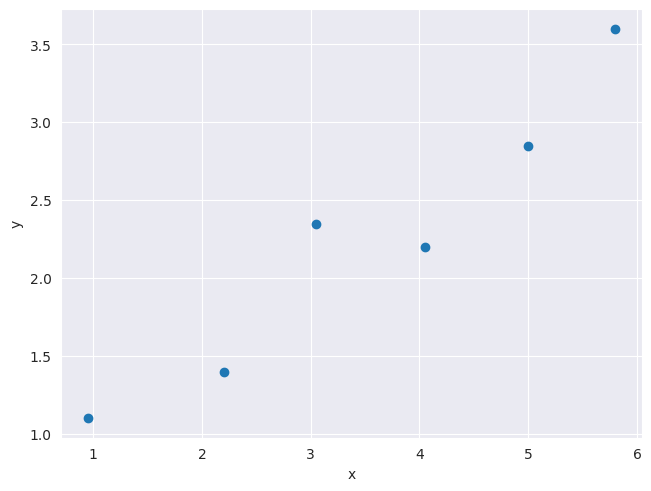

In [45]:
with sns.axes_style('darkgrid'):
    plt.plot(toy_x, toy_y, 'o');
plt.xlabel('x');
plt.ylabel('y');

In [46]:
k, q = linear_regression(toy_x, toy_y)
k, q

(np.float64(0.4908517026354287), np.float64(0.5279286099207046))

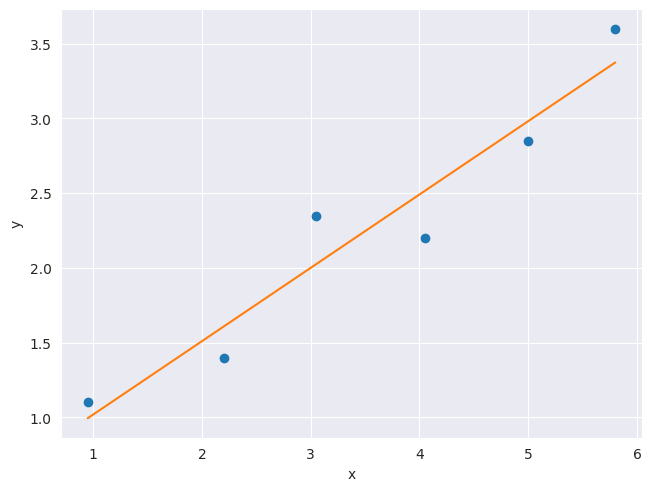

In [47]:
with sns.axes_style('darkgrid'):
    plt.plot(toy_x, toy_y, 'o');
    plt.plot(toy_x, k * toy_x + q, '-');
    plt.xlabel('x');
    plt.ylabel('y');

## Orthogonal least squares

<figure class="image">
  <img src="../figures/edge_primitives-orthogonal_linear_regression.png" alt="Interpolation" style="width: 6.4in;"/>
  <figcaption>
    <br>
    Source: [Burger22], Fig. 10.5
  </figcaption>
</figure>

- Instead of the sum of squared "vertical" errors, we may want to minimize the *orthogonal* distances between the data points and the line.
- The orthogonal distance between a point and a line is easier to define when using the **standard form** of a line (also called algebraic or general)  
  $$
  a \cdot x + b \cdot y + c = 0
  $$
  which also enables us to define perfectly vertical lines by setting $a = 0$ (which is not possible in slope-intercept form as $k$ would have to be $\infty$).
- The (signed) distance of the point $(x_n, y_n)$ from the line $(a, b, c)$
  $$
  d_n = \frac{a \cdot x_n + b \cdot y_n + c}{\sqrt{a^2 + b^2}}
  $$
- Therefore, the task is to minimize the sum  
  $$
  L(a, b, c) = \sum_{i=1}^n{ \left(a \cdot x_n + b \cdot y_n + c\right)^2}
  $$
  which can be written in a matrix form as  
  $$
  \begin{bmatrix}
  \sum x_n^2 & \sum x_n \cdot y_n & \sum x_n \\
  \sum x_n \cdot y_n & \sum y_n^2 & \sum y_n \\
  \sum x_n & \sum y_n & N
  \end{bmatrix}
  \cdot
  \begin{bmatrix}
  a \\
  b \\
  c
  \end{bmatrix}
  =
  \lambda
  \cdot
  \begin{bmatrix}
  a \\
  b \\
  0
  \end{bmatrix}
  $$
  for some $\lambda \ne 0$ (scale does not matter).
- Since the parameter $c$ depends linearly on $a$ and $b$ and can be expressed as (from the last row)  
  $$
  c = -\frac{1}{N}\left(a \cdot \sum x_n + b \cdot \sum y_i\right) = -a \cdot \bar{x} - b \cdot \bar{y}
  $$
  where
  $$
  \bar{x} = \frac{1}{N}\cdot\sum{x_n} \qquad \text{and} \qquad \bar{y} = \frac{1}{N}\cdot\sum{y_n}
  $$
- This means we need to solve  
  $$
  \underbrace{
    \begin{bmatrix}
      \sum{x_n'^2} & \sum{x_n' \cdot y_n'} \\
      \sum{x_n' \cdot y_n'} & \sum{y_n'^2} \\
    \end{bmatrix}
  }_{\bold{S}}
  \cdot
  \underbrace{
    \begin{bmatrix}
      a \\
      b
    \end{bmatrix}
  }_{\bold{\theta}}
  =
  \lambda
  \cdot
  \underbrace{
    \begin{bmatrix}
      a \\
      b
    \end{bmatrix}
  }_{\bold{\theta}}
  $$
  where $x_n' = x_n - \bar{x}$ and $y_n' = y_n - \bar{y}$.
- This a definition of the eigenvalue and eigenvector problem of the form $\bold{S} \cdot \bold{\theta} = \lambda \cdot \bold{\theta}$.
- The solution is the eigenvector associated with the smallest eigenvalue of $\bold{S}$.

In [48]:
def orthogonal_linear_regression(data: np.ndarray, targets: np.ndarray) -> np.ndarray:
    if data.ndim == 1:
        data = data[:, None] # Convert (N,) to (N, 1)
    if targets.ndim == 1:
        targets = targets[:, None] # Convert (N,) to (N, 1)

    # 1. Stack data and targets to treat them symmetrically
    xy = np.hstack((data, targets))  # (N, 2)
    
    # 2. Center the data
    xy_mean = xy.mean(axis=0)
    xyc = xy - xy_mean
    
    # 3. Compute Eigenvectors of the covariance/scatter matrix (S)
    # Use eigh for symmetric matrices (guaranteed real results)
    scatter_matrix = xyc.T @ xyc
    eigvals, eigvecs = np.linalg.eigh(scatter_matrix)
    
    # 4. The normal vector to the hyperplane is the eigenvector 
    # corresponding to the smallest eigenvalue (least variance)
    normal_vector = eigvecs[:, 0] # eigh returns sorted eigenvalues
    
    # 5. Calculate the intercept (d) for the plane equation:
    # normal_vector . [x, y] + d = 0
    # Since the plane passes through the mean: d = -(normal . mean)
    d = -normal_vector @ xy_mean
    
    return np.concatenate((normal_vector, [d]))

In [49]:
a, b, c = orthogonal_linear_regression(toy_x, toy_y)
a, b, c, -a/b, -c/b

(np.float64(0.44645875027559156),
 np.float64(-0.8948042156261652),
 np.float64(0.44698336960867135),
 np.float64(0.4989457386084945),
 np.float64(0.49953203371519855))

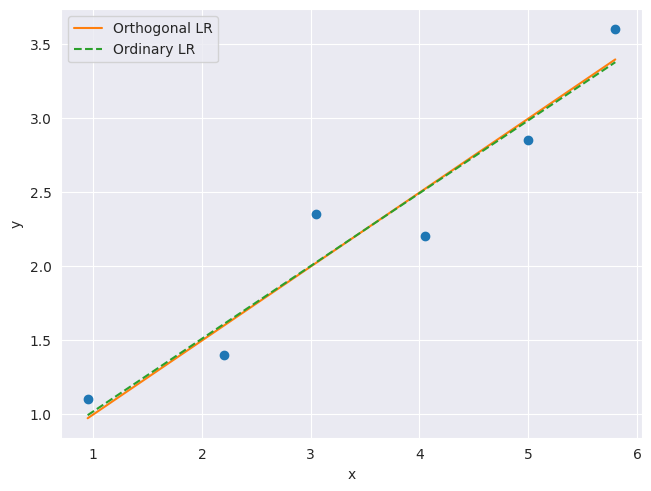

In [50]:
with sns.axes_style('darkgrid'):
    plt.plot(toy_x, toy_y, 'o');
    plt.plot(toy_x, (-a/ b) * toy_x + (-c / b), '-', label='Orthogonal LR');
    plt.plot(toy_x, k * toy_x + q, '--', label='Ordinary LR');
    plt.xlabel('x');
    plt.ylabel('y');
    plt.legend();

# Random Sample Consensus (RANSAC)

## Presence of outliers

- An outlier is a sample that is not part of the original data distribution.
- Outliers typically arise due to data processing errors, e.g. despite the all the pre- and post-processing the Canny detector still returns unwanted edge pixels.
- Due to the square operation, the sum of squares criterion is very sensitive to errors in the model predictions and may give vastly different and incorrect results if the data is corrupted by outliers.

In [51]:
# Insert outlier into the original data
toy_out_x = np.insert(toy_x, 3, 3.5)
toy_out_y = np.insert(toy_y, 3, 5.0)

# And fit again
a_, b_, c_ = orthogonal_linear_regression(toy_out_x, toy_out_y)
a_, b_, c_, -a_/b_, -c_/b_

(np.float64(0.5797890967213276),
 np.float64(-0.8147665943833652),
 np.float64(0.11990852451195178),
 np.float64(0.7116014582803629),
 np.float64(0.1471691713167271))

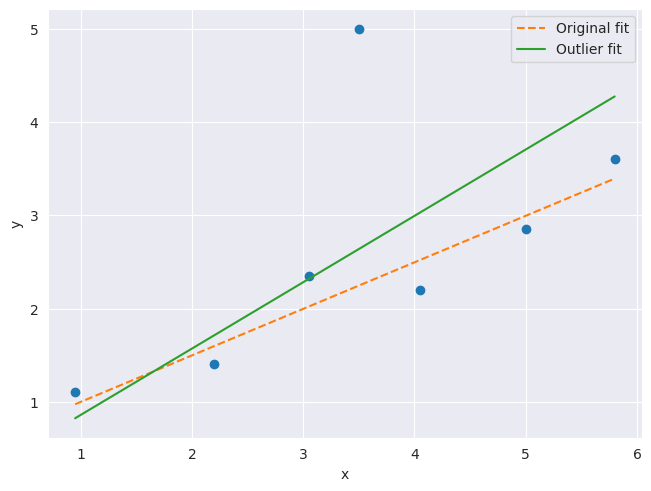

In [52]:
with sns.axes_style('darkgrid'):
    plt.plot(toy_out_x, toy_out_y, 'o');
    plt.plot(toy_out_x, (-a/ b) * toy_out_x + (-c / b), '--', label='Original fit');
    plt.plot(toy_out_x, (-a_/ b_) * toy_out_x + (-c_ / b_), '-', label='Outlier fit');
    plt.xlabel('x');
    plt.ylabel('y');
    plt.legend();

## Robust line fitting using RANSAC

- RANSAC is a robust method for fitting models into data corrupted by outliers.
- It is a Monte Carlo method, i.e. it repeatedly randomly samples data to find the best result.
- Its principle is summarized in the following animation.

<figure class="image">
  <img src="../figures/edge_primitives-ransac.png" alt="Interpolation" style="width: 9.6in;"/>
  <figcaption>
    RANSAC principle.
    <br>
  </figcaption>
</figure>

**How many iterations do we need?**
- If we assume that the ratio of *outliers* in our data is $R$ (e.g. there may be 30 % of outliers, $R = 0.3$),  
  then the probability of randomly selecting an *inlier* is $1 - R$.
- The probability of randomly selecting $N$ (e.g. for line we need $N = 2$ points) inliers therefore is $(1 - R)^N$ (e.g. $(1 - 0.3)^2 = 0.49$).
- This means that we have a $P_\text{out} = 1 - (1 - R)^N$ probability of randomly selecting at least one outlier among $N$ points (e.g. $P_\text{out} = 1 - 0.49 = 51 \%$).
- If we repeat the random selection of $N$ points $T$ times,  
  the probability of *failing* to pick at least one tuple with *all $N$ points being inliers* is $P_\text{out}^T$.
- We may want $P_\text{out}^T$ to be low (e.g. 1 %), i.e.  
  $$
  (1 - (1 - R)^N)^T \le 1 - P
  $$
  where $P$ is the probability of finding the correct parameters (e.g. we want $P = 0.99$).
- Thus, the minimum number of iterations $T$ we need is (solve the inequality for $T$)  
  $$
  
  
  
  T \ge \frac{\log(1-P)}{\log(1 - (1 - R)^N)}
  $$
  where
  - $R \lt 1$ is the assumed ratio of outliers,
  - $P$ is the probability of finding the correct parameters.

In [53]:
def ransac_linear_regression(
    data: np.ndarray,
    targets: np.ndarray,
    num_iterations: int = 0,
    probability: float = 0.99,
    outlier_ratio: float | None = None,
    distance_threshold: float = 0.1,
) -> tuple[np.ndarray, np.ndarray]:
    if data.ndim == 1:
        data = data[:, None]  # Convert (N,) to (N, 1)
    if targets.ndim == 1:
        targets = targets[:, None]  # Convert (N,) to (N, 1)

    num_samples, dim = data.shape
    best_inliers = []
    best_model = np.array([])

    if num_iterations <= 0:
        if outlier_ratio is None:
            raise ValueError("outlier_ratio must be provided if num_iterations is not set")
        # Estimate required number of iterations
        num_iterations = int(np.log(1 - probability) / np.log(1 - (1 - outlier_ratio) ** (dim + 1))) + 1
        # print('RANSAC num_iterations:', num_iterations)

    for _ in range(num_iterations):
        # Randomly sample minimal subset (2 points for line)
        sample_indices = np.random.choice(num_samples, size=dim + 1, replace=False)
        sample_data = data[sample_indices]
        sample_targets = targets[sample_indices]

        # Fit model to the sample
        model_params = orthogonal_linear_regression(sample_data, sample_targets)
        xy1 = np.hstack((data, targets, np.ones((num_samples, 1))))

        # Compute distances to the model
        distances = np.abs(xy1 @ model_params[:, None]) / np.sqrt((model_params[:-1] ** 2).sum())

        # Identify inliers
        inliers = np.where(distances < distance_threshold)[0]

        # Update best model if current one has more inliers
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = model_params

            # Early stopping if enough inliers are found
            if len(best_inliers) > (1.0 - outlier_ratio) * num_samples:
                break

    # Refit model using all inliers
    if len(best_inliers) > 0:
        final_data = data[best_inliers]
        final_targets = targets[best_inliers]
        best_model = orthogonal_linear_regression(final_data, final_targets)

    return best_model, best_inliers

In [54]:
(a_r, b_r, c_r), inliners = ransac_linear_regression(toy_out_x, toy_out_y, probability=0.99, outlier_ratio=2/7, distance_threshold=0.5)
a_r, b_r, c_r, -a_r/b_r, -c_r/b_r

(np.float64(0.44645875027559156),
 np.float64(-0.8948042156261652),
 np.float64(0.44698336960867135),
 np.float64(0.4989457386084945),
 np.float64(0.49953203371519855))

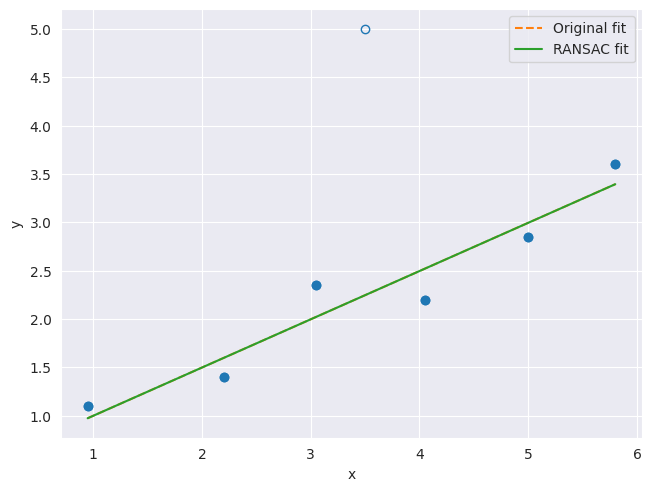

In [55]:
with sns.axes_style('darkgrid'):
    p = plt.plot(toy_out_x, toy_out_y, 'o', markerfacecolor='none');
    plt.plot(toy_out_x[inliners], toy_out_y[inliners], 'o', c=p[0].get_color());
    plt.plot(toy_out_x, (-a/ b) * toy_out_x + (-c / b), '--', label='Original fit');
    plt.plot(toy_out_x, (-a_r/ b_r) * toy_out_x + (-c_r / b_r), '-', label='RANSAC fit');
    plt.xlabel('x');
    plt.ylabel('y');
    plt.legend();

In [56]:
sunset_rgb = skimage.io.imread('../data/sunset.jpg')
sunset_rgb = skimage.util.img_as_float(sunset_rgb)
sunset_rgb = skimage.transform.rescale(sunset_rgb, 0.2, channel_axis=2)
sunset_gray = skimage.color.rgb2gray(sunset_rgb)
sunset_gray.shape, sunset_gray.dtype, sunset_gray.min(), sunset_gray.max()

((404, 846),
 dtype('float64'),
 np.float64(0.004636872968438395),
 np.float64(1.0))

In [57]:
sunset_canny_bw = canny(sunset_gray, sigma=1.0, t_lo=0.2, t_hi=0.4)
sunset_canny_bw.shape, sunset_canny_bw.dtype, sunset_canny_bw.min(), sunset_canny_bw.max()

((404, 846), dtype('bool'), np.False_, np.True_)

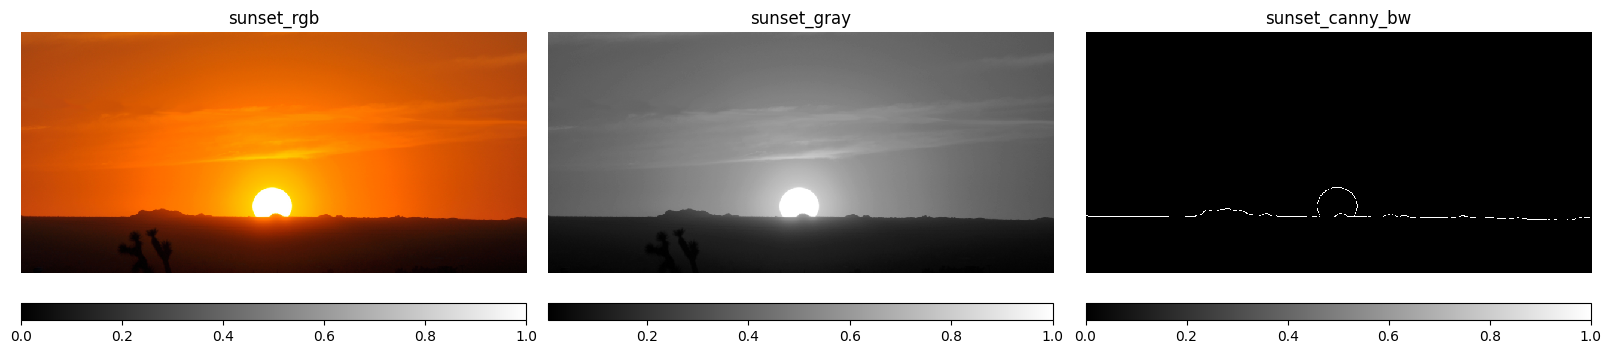

In [58]:
imshow_grid(sunset_rgb=sunset_rgb, sunset_gray=sunset_gray, sunset_canny_bw=sunset_canny_bw, cmap='gray', figsize=(16, 6));

In [59]:
# Find edge pixel coordinates - this is our (x, y) data for line fitting
ys, xs = np.nonzero(sunset_canny_bw)
xs, ys

(array([412, 413, 414, 415, 416, 417, 418, 419, 420, 421, ..., 800, 801, 802, 803, 806, 807, 808, 809, 810, 811], shape=(1032,)),
 array([261, 261, 261, 261, 261, 261, 261, 261, 261, 261, ..., 315, 315, 315, 315, 315, 315, 315, 315, 315, 315], shape=(1032,)))

In [60]:
# Fit line using RANSAC
sunset_hor_line, sunset_hor_line_inliers = ransac_linear_regression(xs, ys, probability=0.99, outlier_ratio=0.4, distance_threshold=2.0)
sunset_hor_line

array([  0.004,  -1.   , 308.457])

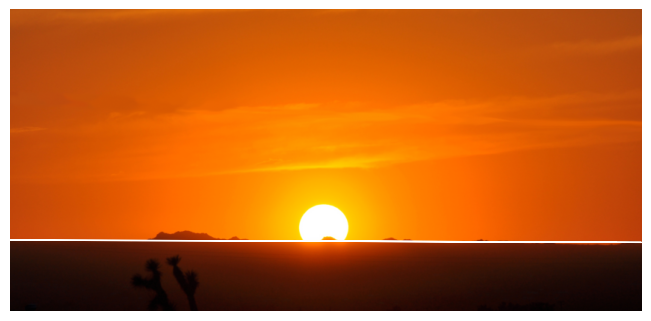

In [61]:
plt.imshow(sunset_rgb);
plt.axis('off');
plt.plot(xs, (-sunset_hor_line[0]/ sunset_hor_line[1]) * xs + (-sunset_hor_line[2] / sunset_hor_line[1]), '-', color='w', linewidth=1);

# Hough transform for line detection

- For better mathematical convenience, Hough transform works with lines in the **Hessian normal form (HNF)**, in which every point $(x,y)$ satisfies
  $$
  r = x \cdot \cos(\theta) + y \cdot \sin(\theta)
  $$
  where
  - $\theta$ represents line orientation (angle),
  - $r$ is a distance from the center of the coordinate system; see the following figure.
  <figure>
      <img src="../figures/edge_primitives-r_theta_line.gif" style="width: 3.2in;"/>
      <figcaption>Figure source: <a href="https://en.wikipedia.org/wiki/Hough_transform">https://en.wikipedia.org/wiki/Hough_transform</a></figcaption>
  </figure>
- Hough transform then works as a voting scheme, in which every point votes for all lines passing through it.
- The method proceeds as follows
  1. Initialize a 2D accumulator table $A(\theta,r)$ to zeros. Each entry $(\theta,r)$ in $A$ represents one of the lines that can appear in our image.
  2. For each non-zero point $(x,y)$ in our binary image:
     1. For each line angle $\theta_i = 0\degree,\ldots,180\degree$
        1. Calculate
           $$
           r_i = x \cdot \cos(\theta_i) + y \cdot \sin(\theta_i)
           $$
           i.e. distance $r_i$ from the origin of the line with angle $\theta_i$ passing through point $(x,y)$
        2. Vote for computed line $(\theta_i,r_i)$ in the accumulator table:
           $$
           A(\theta_i,r_i) \leftarrow A(\theta_i,r_i) + 1
           $$
  3. Find local maximums with sufficient number of votes in the accumulator table $A$. Each such maximum represents one of the detected lines in the image.
- For example, in the following figure we see 3 points (black dots) and only consider the angles $\theta_i = 0\degree, 15\degree, 30\degree, 45\degree, 60\degree, 75\degree$.
- Each point votes for 5 lines that pass through it.
- The blue line corresponding to angle $\theta = 60\degree$ and distance $r$ in the interval $[400, 410]$ gets 3 votes, because it is common to all the 3 points.
- All the other lines only get one vote each, because they do not pass through more than one point (they each have different $r$).
  <figure>
      <img src="../figures/edge_primitives-hough_transform_diagram.png" style="width: 12.8in; background-color: white"/>
      <figcaption>Figure source: <a href="https://en.wikipedia.org/wiki/Hough_transform">https://en.wikipedia.org/wiki/Hough_transform</a></figcaption>
  </figure>

In [62]:
def hough_line_transform(
    bw: np.ndarray,
    dist_res: float = 1.0,
    angle_res: float = np.pi / 180,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    height, width = bw.shape
    diagonal = int(np.ceil(np.sqrt(height ** 2 + width ** 2)))
    dists = np.arange(-diagonal, diagonal + dist_res, dist_res)
    angles = np.arange(0, np.pi, angle_res)

    accumulator = np.zeros((len(dists), len(angles)), dtype=int)

    for y, x in zip(*np.nonzero(bw)):
        for ti in range(len(angles)):
            dist = x * np.cos(angles[ti]) + y * np.sin(angles[ti])
            di = int(round((dist + diagonal) / dist_res))
            accumulator[di, ti] += 1

    return accumulator, dists, angles

In [63]:
def find_local_maxima(arr: np.ndarray, threshold: int = 0, neighborhood_size: int = 3) -> np.ndarray:
    filtered = scipy.ndimage.maximum_filter(arr, size=neighborhood_size)
    local_max = (arr == filtered) & (arr >= threshold)
    return np.argwhere(local_max)

In [64]:
sunset_hough_acc, sunset_hough_rhos, sunset_hough_thetas = hough_line_transform(sunset_canny_bw, dist_res=1.0, angle_res=np.pi / 180)
sunset_hough_acc.shape, sunset_hough_rhos.shape, sunset_hough_thetas.shape

((1877, 180), (1877,), (180,))

In [65]:
sunset_lines_peaks = find_local_maxima(sunset_hough_acc, threshold=100, neighborhood_size=51)
sunset_lines_peaks

array([[1247,   90]])

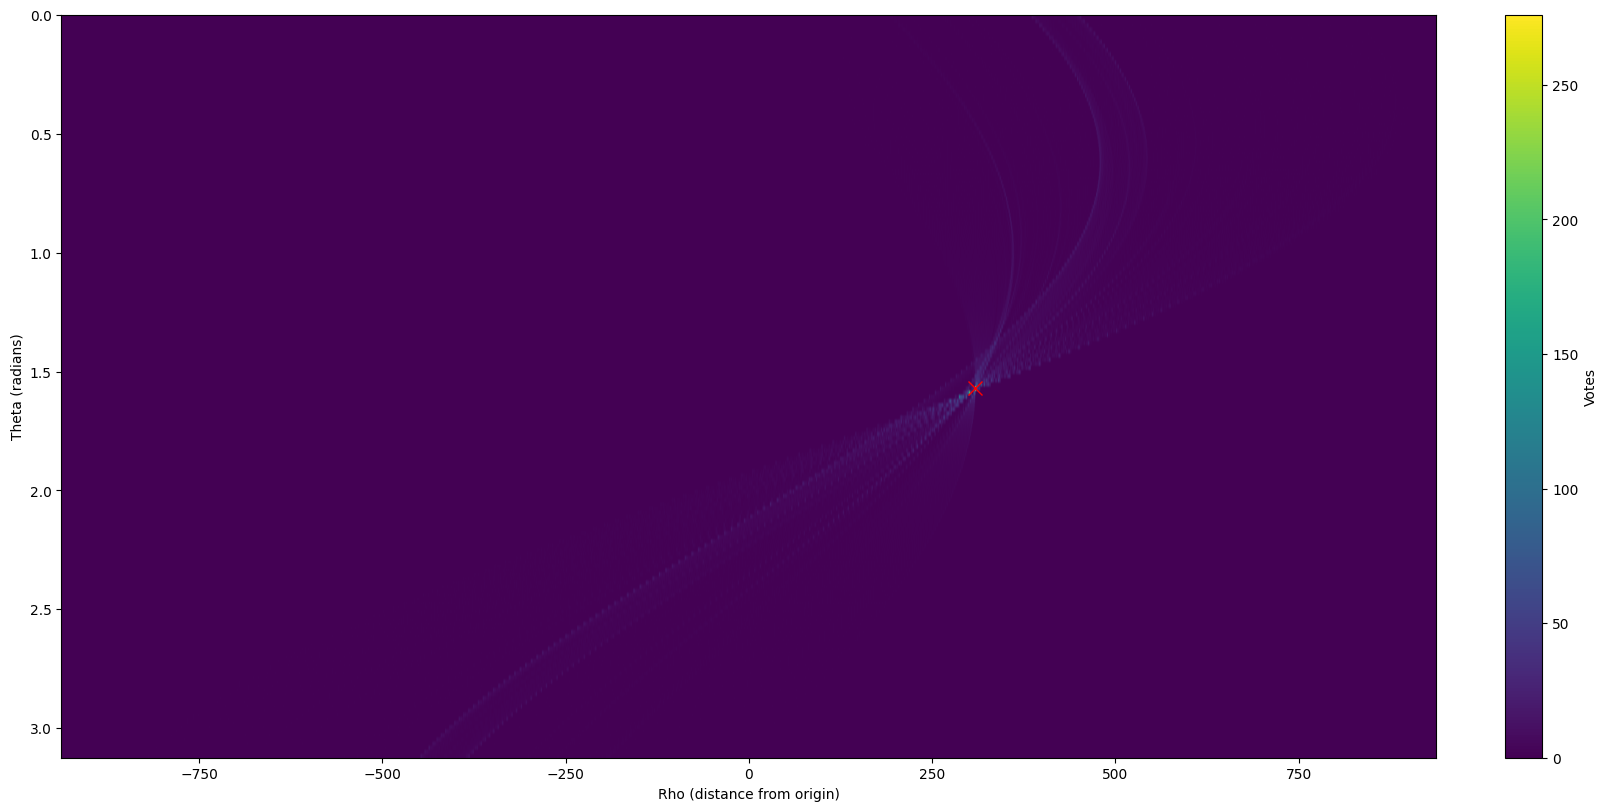

In [66]:
plt.figure(figsize=(16, 8));
plt.imshow(sunset_hough_acc.T, aspect='auto', extent=[sunset_hough_rhos[0], sunset_hough_rhos[-1], sunset_hough_thetas[-1], sunset_hough_thetas[0]]);
plt.plot(sunset_hough_rhos[sunset_lines_peaks[:, 0]], sunset_hough_thetas[sunset_lines_peaks[:, 1]], 'x', markersize=10, color='red');
plt.xlabel('Rho (distance from origin)');
plt.ylabel('Theta (radians)');
plt.colorbar(label='Votes');

In [67]:
sunset_hor_hough_line = np.cos(sunset_hough_thetas[sunset_lines_peaks[0, 1]]), np.sin(sunset_hough_thetas[sunset_lines_peaks[0, 1]]), -sunset_hough_rhos[sunset_lines_peaks[0, 0]]
sunset_hor_hough_line

(np.float64(6.123233995736766e-17), np.float64(1.0), np.float64(-309.0))

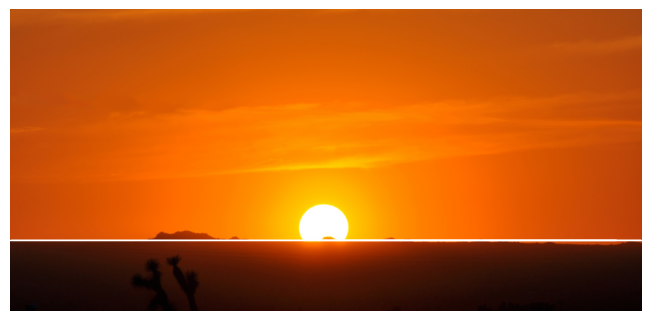

In [68]:
plt.imshow(sunset_rgb);
plt.axis('off');
plt.plot(xs, (-sunset_hor_hough_line[0]/ sunset_hor_hough_line[1]) * xs + (-sunset_hor_hough_line[2] / sunset_hor_hough_line[1]), '-', color='w', linewidth=1);

In [69]:
# An example 
tiles_rgb = skimage.io.imread('../data/tiles.png')
tiles_rgb = skimage.util.img_as_float(tiles_rgb)
tiles_canny_bw = canny(skimage.color.rgb2gray(tiles_rgb), sigma=2.0, t_lo=0.1, t_hi=0.3)

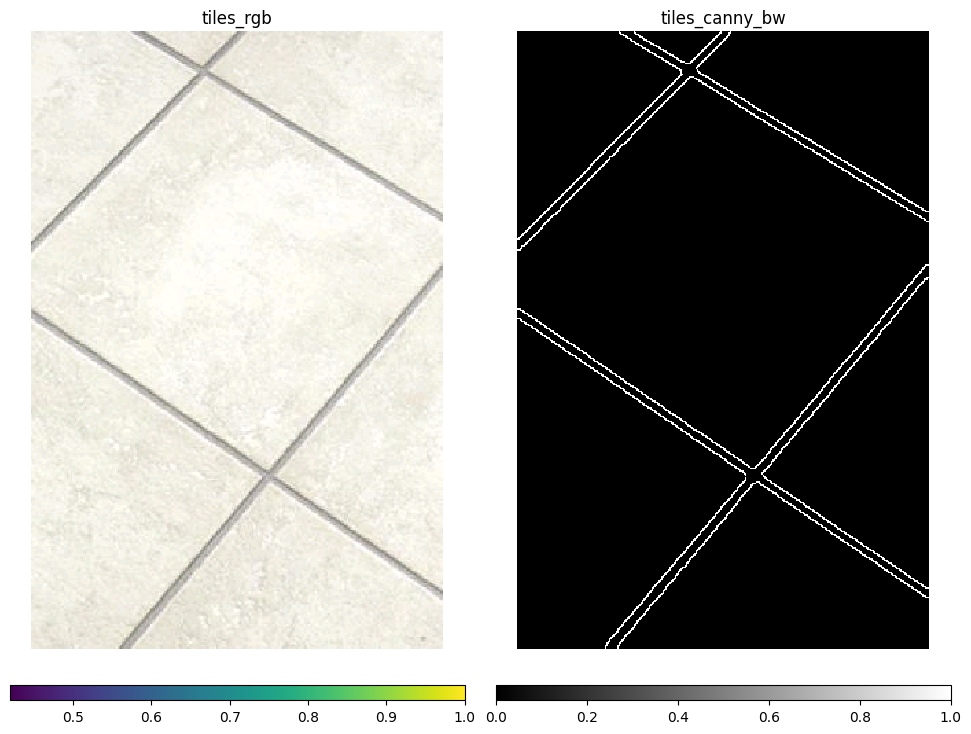

In [70]:
imshow_grid(tiles_rgb=tiles_rgb, tiles_canny_bw=tiles_canny_bw);

In [71]:
tiles_hough_acc, tiles_hough_rhos, tiles_hough_thetas = hough_line_transform(tiles_canny_bw, dist_res=1.0, angle_res=np.pi / 180)
tiles_lines_peaks = find_local_maxima(tiles_hough_acc, threshold=150, neighborhood_size=5)
tiles_lines_peaks

array([[501, 122],
       [504, 121],
       [648,  45],
       [653,  44],
       [704, 125],
       [715, 124],
       [878,  40],
       [884,  40]])

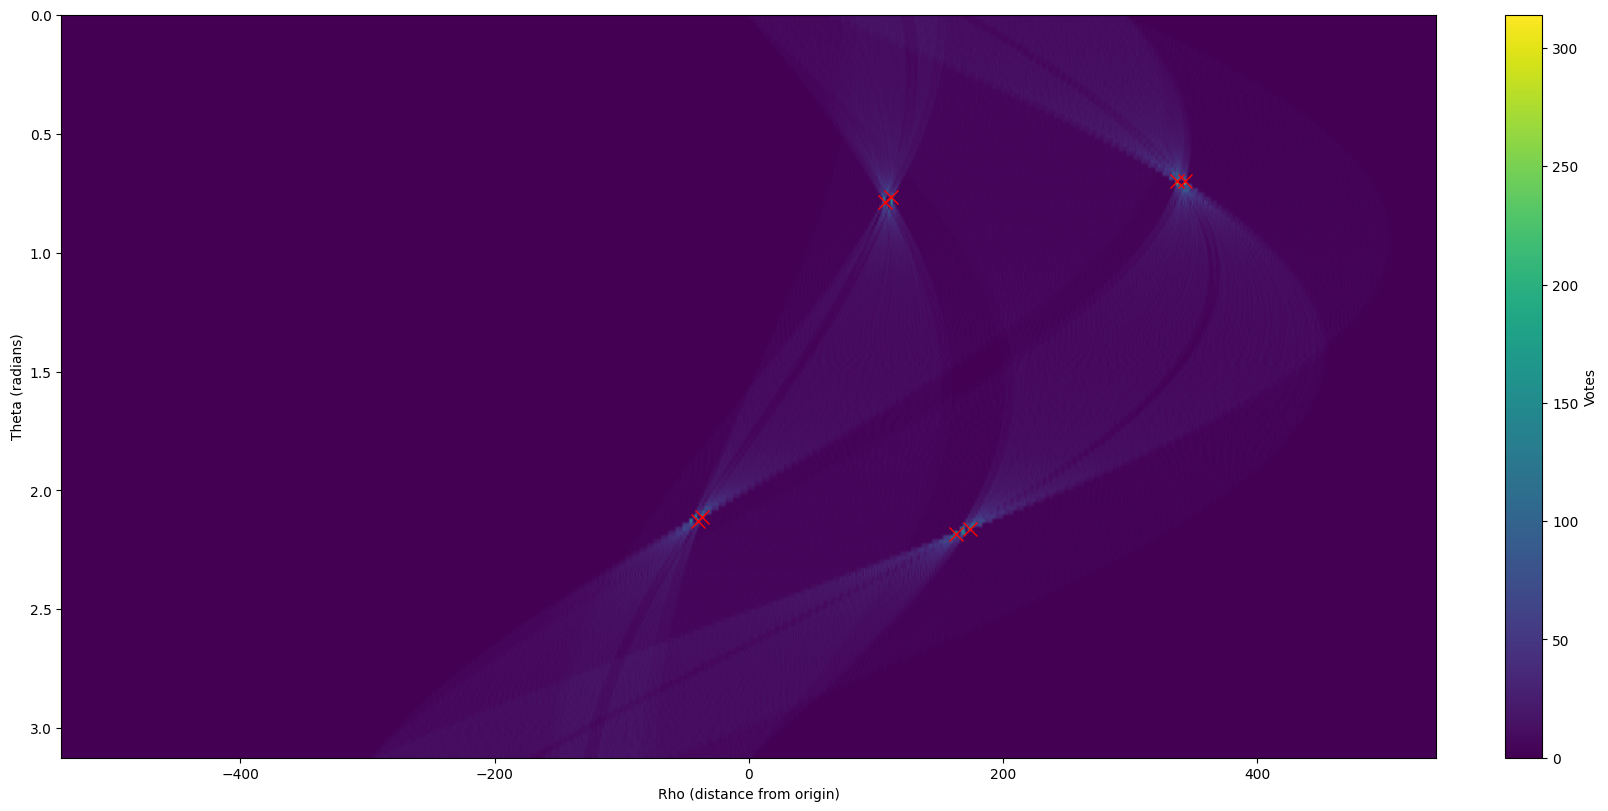

In [72]:
plt.figure(figsize=(16, 8));
plt.imshow(tiles_hough_acc.T, aspect='auto', extent=[tiles_hough_rhos[0], tiles_hough_rhos[-1], tiles_hough_thetas[-1], tiles_hough_thetas[0]]);
plt.plot(tiles_hough_rhos[tiles_lines_peaks[:, 0]], tiles_hough_thetas[tiles_lines_peaks[:, 1]], 'x', markersize=10, color='red');
plt.xlabel('Rho (distance from origin)');
plt.ylabel('Theta (radians)');
plt.colorbar(label='Votes');

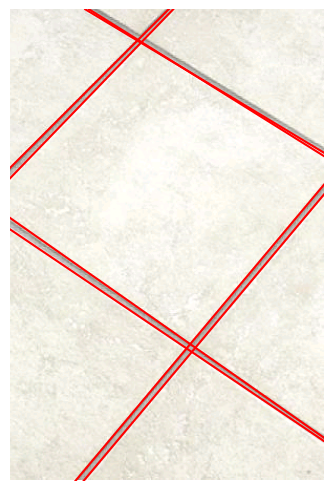

In [73]:
plt.imshow(tiles_rgb);
plt.axis('off');
plt.xlim(0, tiles_rgb.shape[1]);
plt.ylim(tiles_rgb.shape[0], 0);
for peak in tiles_lines_peaks:
    dist = tiles_hough_rhos[peak[0]]
    theta = tiles_hough_thetas[peak[1]]
    y1 = dist / np.sin(theta) if theta not in (-np.pi, 0., np.pi) else 1e9
    x2 = dist / np.cos(theta) if theta not in (-np.pi / 2., np.pi / 2.) else 1e9
    plt.axline((0, y1 if not np.isinf(y1) else 1e9), (x2 if not np.isinf(x2) else 1e9, 0), color=(1, 0, 0))

# Hough transform for circles

In [74]:
coins2_rgb = skimage.io.imread('../data/coins2.jpg')
coins2_rgb = skimage.util.img_as_float(coins2_rgb)
coins2_gray = skimage.color.rgb2gray(coins2_rgb)
coins2_edges = skimage.feature.canny(coins2_gray, sigma=1., low_threshold=0.3, high_threshold=0.6)

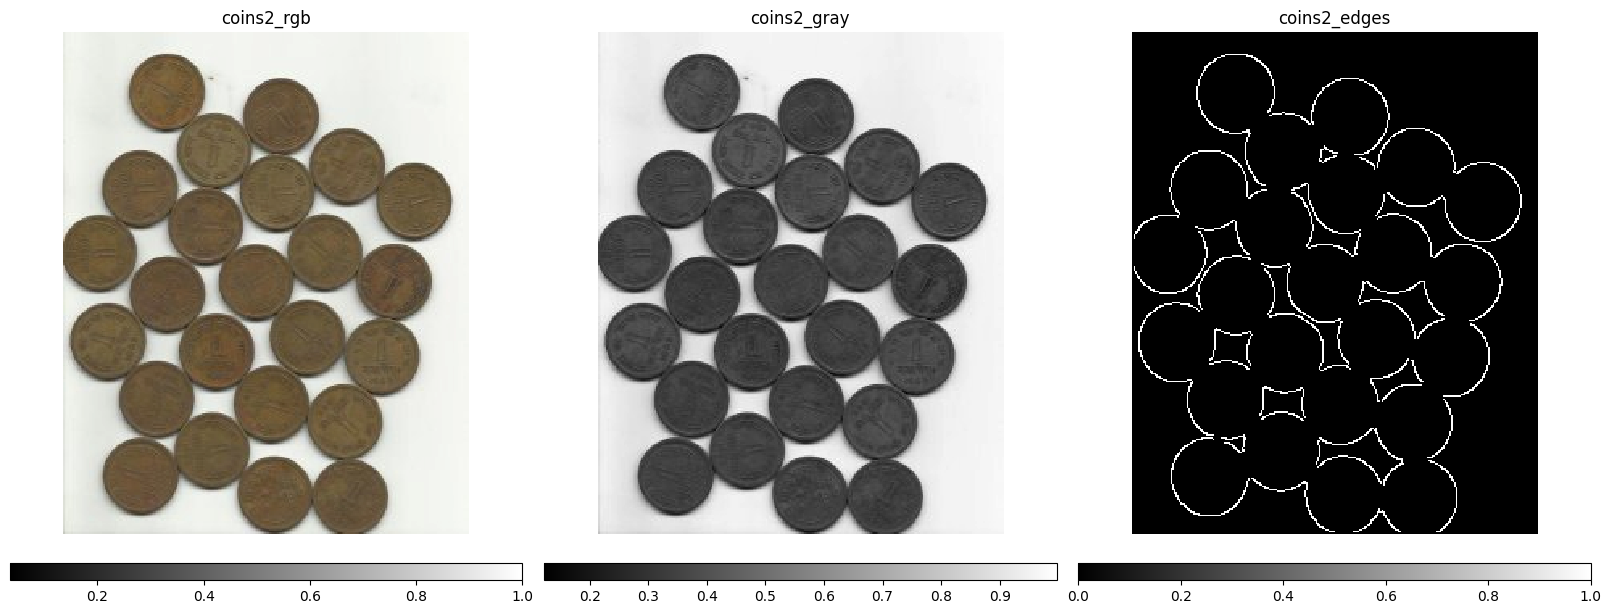

In [75]:
imshow_grid(coins2_rgb=coins2_rgb, coins2_gray=coins2_gray, coins2_edges=coins2_edges, cmap='gray', figsize=(16, 6));

In [76]:
coins2_radii = np.linspace(20., 30., 20)
coins2_accum = skimage.transform.hough_circle(coins2_edges, coins2_radii, normalize=True)  # normalize is True by default
coins2_accum.shape  # accumulator table for each radius

(20, 312, 252)

In [77]:
coins2_votes, coins2_cx, coins2_cy, coins2_radii = skimage.transform.hough_circle_peaks(
    coins2_accum,
    coins2_radii,
    min_xdistance = 10,
    min_ydistance = 10,
    threshold = 0.5 * coins2_accum.max()
)
coins2_votes.shape, coins2_cx.shape, coins2_cy.shape, coins2_radii.shape

((24,), (24,), (24,), (24,))

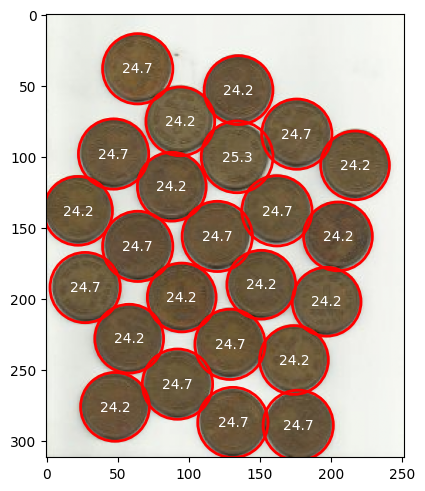

In [78]:
fig, ax = plt.subplots()
ax.imshow(coins2_rgb);
for acc_val, cx, cy, rad in zip(coins2_votes, coins2_cx, coins2_cy, coins2_radii):
    c = plt.Circle((cx, cy), rad, color='r', linewidth=2, fill=False)
    ax.add_patch(c)
    ax.text(cx, cy, f"{rad:.1f}", color='w', horizontalalignment='center', verticalalignment='center')